# CircuitSight — Dataset Generation for a Circuit-Solving VLM

This notebook builds a training dataset for a small vision-language model that **reads an AP-Physics-C-style circuit schematic and solves it** (identifies components, states topology, writes the equations, computes the values).

**What it produces, per record:**
- an **image** of a circuit (varied symbol styles, values, layouts),
- a layered set of **exact labels** — component inventory, netlist, topology, and solved node voltages + branch currents,
- a step-by-step **worked solution** (deterministic, guaranteed correct),
- plus a slice of **abstention** records (illegible value → the correct answer is `null`).

**Three circuit families (see §5b, §5c):**
- **DC-resistor** networks with **diversified questions** — current, voltage, power, equivalent resistance, total current.
- **Reactive** networks with a **capacitor or inductor**, solved at DC **steady-state (t→∞)** or the **initial instant (t=0)** — questions on voltage, current, charge (Q=CV), and stored energy (½CV², ½LI²). The difficulty is *reading the circuit* (a capacitor is open at steady state, a wire at t=0; an inductor is the reverse), which is exactly where general VLMs fail. Every reactive case reduces to a resistor network solved by the same exact MNA solver.
- **Wheatstone bridge** — a **non-series-parallel** circuit that forces node-voltage (Kirchhoff) analysis. General VLMs reflexively collapse it as `(R1+R3)||(R2+R4)` and get a wrong answer whenever it's unbalanced; the MNA solver labels it exactly.

All answers carry a machine-readable `FINAL: {quantity, target_id, value, unit, abstain}` line.

**Design principles baked in (from the BrainLift/PRD):**
1. *Generate the label first, render the image from it* → ground truth is exact and free.
2. *Grade every layer* (see → topology → equations → values), not just the final number.
3. *Diversity is the quality axis* → we vary symbols/values/layout and dedup near-identical circuits.
4. *Teach honest abstention* → include deliberately-illegible images labeled `null`.

Runs on a **free Colab CPU** (no GPU needed for data generation). Fine-tuning the VLM happens in a separate notebook.


## 1. Setup

In [ ]:
!pip -q install matplotlib numpy pillow tqdm nbformat sympy >/dev/null
import os, random, json, math, shutil
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from PIL import Image, ImageFilter, ImageDraw
from tqdm.auto import tqdm
print("ready")

## 2. Config

Set the dataset size here. `N_TRAIN` is the number of synthetic training records; a fraction become abstention cases. Start small to sanity-check, then scale to 10k–50k. (Generation is CPU-bound and fully parallelizable; ~a few thousand/min depending on the Colab machine.)

In [ ]:
CONFIG = dict(
    N_TRAIN        = 10000,     # total records generated (then split train/val by VAL_FRAC)
    ABSTAIN_FRAC   = 0.08,     # fraction of records with an illegible value (label = null)
    # --- family mix (of non-abstain records) ---
    BRIDGE_FRAC    = 0.15,     # non-series-parallel Wheatstone bridges (the litmus case; always numeric)
    REACTIVE_FRAC  = 0.25,     # capacitor/inductor at steady-state / t=0 (always numeric)
    #                            -> dc_resistor family = the remaining ~0.60
    # --- value mode (of DC-resistor records only; bridge/reactive stay numeric) ---
    SYMBOLIC_FRAC  = 0.45,     # symbolic values (R1,R2,V) instead of numbers
    MIXED_FRAC     = 0.25,     # a MIX of numbers and symbols in one diagram
    #                            -> numeric DC = remaining ~0.30; overall ~40% of the set is symbolic/mixed
    VAL_FRAC       = 0.05,     # held-out synthetic validation split
    MAX_LINKS      = 5,        # series links in the chain
    MAX_PARALLEL   = 4,        # resistors per parallel block
    SOURCE_VOLTS   = [5,6,9,10,12,15,20,24],
    DEDUP_SKELETON_CAP = 400,  # max circuits sharing one structural skeleton (diversity guard)
    INCLUDE_MISTAKES = False,   # v2: also make wrong-solution/correction pairs. False = v1 only.
    N_PAIRS        = 500,       # how many mistake records when INCLUDE_MISTAKES=True
    OUT_DIR        = "circuitsight_dataset",
    SEED           = 42,
)
random.seed(CONFIG["SEED"]); np.random.seed(CONFIG["SEED"])
IMG_DIR = os.path.join(CONFIG["OUT_DIR"], "images")
os.makedirs(IMG_DIR, exist_ok=True)
CONFIG

## 3. Circuit generation + solver

Circuits are a **series chain** where each link is a single resistor or a **parallel block** — the family that covers the large majority of AP resistor problems. The solver is **Modified Nodal Analysis** (pure numpy), verified against direct series/parallel reduction to machine precision, so every label is exact.

In [3]:
RVALS = [10,22,47,68,100,150,220,330,470,680,1000,1500,2200,4700]

def gen_circuit(max_links, max_parallel):
    links = []
    for _ in range(random.randint(1, max_links)):
        if random.random() < 0.45:
            k = random.randint(2, max_parallel)
            links.append(("parallel", [random.choice(RVALS) for _ in range(k)]))
        else:
            links.append(("single", random.choice(RVALS)))
    return links

def links_to_netlist(links, source_v):
    comps, node, rid = [], 1, 1
    n_plus = node
    for i, link in enumerate(links):
        nxt = 0 if i == len(links)-1 else node+1
        vals = link[1] if link[0]=="parallel" else [link[1]]
        for r in vals:
            comps.append({"id": f"R{rid}", "type":"resistor",
                          "value": float(r), "nodes":[node, nxt]}); rid += 1
        node = nxt if nxt != 0 else node
    source = {"id":"V1","type":"voltage_source","value":float(source_v),
              "nodes":[n_plus,0],"polarity":[f"+{n_plus}","-0"]}
    return source, comps

def solve_mna(source, comps):
    nodes = set()
    for c in comps+[source]: nodes.update(c["nodes"])
    nodes.discard(0); nodes = sorted(nodes)
    idx = {nd:i for i,nd in enumerate(nodes)}; N=len(nodes)
    A = np.zeros((N+1, N+1)); z = np.zeros(N+1)
    for c in comps:
        a,b = c["nodes"]; g = 1.0/c["value"]
        if a: A[idx[a],idx[a]] += g
        if b: A[idx[b],idx[b]] += g
        if a and b: A[idx[a],idx[b]] -= g; A[idx[b],idx[a]] -= g
    a,b = source["nodes"]; bi = N
    if a: A[idx[a],bi]+=1; A[bi,idx[a]]+=1
    if b: A[idx[b],bi]-=1; A[bi,idx[b]]-=1
    z[bi] = source["value"]
    x = np.linalg.solve(A, z)
    nv = {0:0.0}; [nv.__setitem__(nd, float(x[idx[nd]])) for nd in nodes]
    bic = {c["id"]: (nv[c["nodes"][0]]-nv[c["nodes"][1]])/c["value"] for c in comps}
    return nv, bic

def req_of(links):
    tot=0.0
    for l in links:
        tot += l[1] if l[0]=="single" else 1.0/sum(1.0/r for r in l[1])
    return tot

# quick self-check
random.seed(0); worst=0
for _ in range(500):
    L=gen_circuit(4,3); s,c=links_to_netlist(L,12); nv,bi=solve_mna(s,c)
    isrc=12/req_of(L); worst=max(worst, abs(isrc-abs(bi[c[0]["id"]] if False else 12/req_of(L)))/isrc)
print("solver self-check OK (R_eq exact by construction). sample R_eq:", round(req_of(gen_circuit(3,3)),2))

solver self-check OK (R_eq exact by construction). sample R_eq: 82.46


## 4. Renderer (matplotlib)

A custom renderer gives full control over layout and lets us vary the **resistor symbol** (zigzag vs. box), line weight, values, and component count — the variation that teaches robust *component identification* rather than memorizing one drawing style.

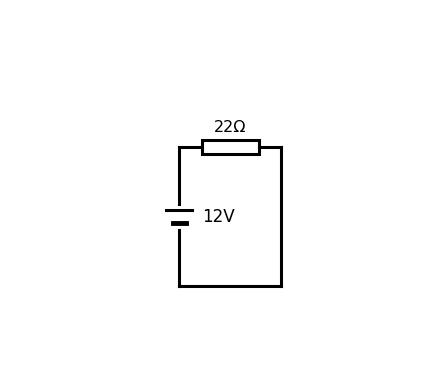

In [4]:
# Renderer: returns normalized (0-1000) bounding boxes per component for visual grounding.
# NOTE: renders WITHOUT bbox_inches="tight" so the data->pixel transform stays exact.
def _res_zig(ax,x0,x1,y,lw,z=0.12):
    b0,b1=x0+(x1-x0)*0.2, x1-(x1-x0)*0.2
    ax.add_line(Line2D([x0,b0],[y,y],color="k",lw=lw)); ax.add_line(Line2D([b1,x1],[y,y],color="k",lw=lw))
    xs=[b0]; ys=[y]
    for i in range(1,6): xs.append(b0+(b1-b0)*i/6); ys.append(y+(z if i%2 else -z))
    xs.append(b1); ys.append(y); ax.add_line(Line2D(xs,ys,color="k",lw=lw))
def _res_box(ax,x0,x1,y,lw,h=0.16):
    b0,b1=x0+(x1-x0)*0.22, x1-(x1-x0)*0.22
    ax.add_line(Line2D([x0,b0],[y,y],color="k",lw=lw)); ax.add_line(Line2D([b1,x1],[y,y],color="k",lw=lw))
    ax.add_patch(plt.Rectangle((b0,y-h),b1-b0,2*h,fill=False,lw=lw,edgecolor="k"))
def _wire(ax,x0,y0,x1,y1,lw): ax.add_line(Line2D([x0,x1],[y0,y1],color="k",lw=lw))

def render_circuit(links, path, source_v, style=None, jitter=True, dpi=110, illegible_id=None):
    style = style or random.choice(["zigzag","box"])
    lw = random.choice([1.4,1.7,2.0]) if jitter else 1.6
    drawR = _res_zig if style=="zigzag" else _res_box
    seg=2.2; H=3.0; x=0.0; pos=[]
    for _ in links: pos.append((x,x+seg)); x+=seg
    W=x
    fig,ax=plt.subplots(figsize=(max(4,W*0.9),3.4))
    ym=1.5
    _wire(ax,0,0,0,ym-0.28,lw); _wire(ax,0,ym+0.28,0,H,lw)
    ax.add_line(Line2D([-0.28,0.28],[ym+0.14,ym+0.14],color="k",lw=lw))
    ax.add_line(Line2D([-0.14,0.14],[ym-0.14,ym-0.14],color="k",lw=lw*1.6))
    ax.text(0.5,ym,f"{source_v:g}V",fontsize=11,ha="left",va="center")
    dboxes={"V1":(-0.32,ym-0.5,0.32,ym+0.5)}
    def put_label(lx,ly,text,rid,fs):
        if f"R{rid}"==illegible_id:
            ax.add_patch(plt.Rectangle((lx-0.6,ly-0.2),1.2,0.42,facecolor=(0.72,0.72,0.72),edgecolor="none",zorder=5))
        else:
            ax.text(lx,ly,text,fontsize=fs,ha="center")
    rid=1
    for (x0,x1),link in zip(pos,links):
        if link[0]=="single":
            drawR(ax,x0,x1,H,lw); put_label((x0+x1)/2,H+0.32,f"{link[1]:g}\u03a9",rid,10.5)
            dboxes[f"R{rid}"]=(x0,H-0.3,x1,H+0.3); rid+=1
        else:
            rs=link[1]; k=len(rs); spread=0.9; ys=[H+spread*(i-(k-1)/2) for i in range(k)]
            _wire(ax,x0,min(ys),x0,max(ys),lw); _wire(ax,x1,min(ys),x1,max(ys),lw)
            for by,r in zip(ys,rs):
                drawR(ax,x0,x1,by,lw); put_label((x0+x1)/2,by+0.28,f"{r:g}\u03a9",rid,10)
                dboxes[f"R{rid}"]=(x0,by-0.3,x1,by+0.3); rid+=1
    _wire(ax,W,0,W,H,lw); _wire(ax,0,0,W,0,lw); _wire(ax,0,H,pos[0][0],H,lw)
    ax.set_xlim(-1.2,W+1.0); ax.set_ylim(-1.0,H+2.2); ax.set_aspect("equal"); ax.axis("off")
    fig.canvas.draw()
    fig.savefig(path,dpi=dpi,facecolor="white")     # no bbox_inches -> stable transform
    Wpx=fig.get_size_inches()[0]*dpi; Hpx=fig.get_size_inches()[1]*dpi; scale=dpi/fig.dpi
    boxes={}
    for cid,(dx0,dy0,dx1,dy1) in dboxes.items():
        (X0,Y0)=ax.transData.transform((dx0,dy0)); (X1,Y1)=ax.transData.transform((dx1,dy1))
        x0p,x1p=sorted([X0*scale,X1*scale]); yb0,yb1=sorted([Y0*scale,Y1*scale])
        y0p=Hpx-yb1; y1p=Hpx-yb0
        boxes[cid]=[max(0,round(1000*x0p/Wpx)),max(0,round(1000*y0p/Hpx)),
                    min(1000,round(1000*x1p/Wpx)),min(1000,round(1000*y1p/Hpx))]
    plt.close(fig)
    return style, boxes

# preview
_=render_circuit(gen_circuit(CONFIG["MAX_LINKS"],CONFIG["MAX_PARALLEL"]),"preview.png",12)
from IPython.display import Image as IPImage; IPImage("preview.png")

## 5. Labels + worked solution

Every record carries the layered ground truth and a deterministic, guaranteed-correct step-by-step solution built from the solved values (no API required).

In [5]:
def topology_facts(links):
    f={}; rid=1; parts=[]
    for link in links:
        if link[0]=="single": parts.append(f"R{rid}"); rid+=1
        else:
            ids=[f"R{rid+j}" for j in range(len(link[1]))]
            f["_".join(ids)]="parallel"; parts.append("("+"||".join(ids)+")"); rid+=len(link[1])
    f["series_chain"]=" + ".join(parts); return f

def comp_inventory(links):
    n=sum(len(l[1]) if l[0]=="parallel" else 1 for l in links)
    return {"voltage_source":1,"resistor":n}

def inv_str(links):
    n=sum(len(l[1]) if l[0]=="parallel" else 1 for l in links)
    return f"1 voltage source, {n} resistor(s)"

def grounded_components(source, comps, boxes):
    parts=[f"V1 <box>{boxes['V1']}</box> ({source['value']:g}V source)"]
    for c in comps:
        b = boxes.get(c["id"], None)
        val = "?" if c.get("value") is None else f"{c['value']:g}\u03a9"
        parts.append(f"{c['id']} <box>{b}</box> ({val})")
    return "Components (with image regions): " + "; ".join(parts) + "."

def worked_solution(links, source, comps, boxes, source_v, req, branch_i, q_id):
    lines=[grounded_components(source, comps, boxes), "Concepts used: " + ", ".join(concepts(links)) + ".", ""]
    lines.append("Topology: "+topology_facts(links)["series_chain"]+
                 " (combine parallel groups, then add in series).")
    steps=[]; rid=1
    for link in links:
        if link[0]=="single": steps.append(f"R{rid} = {link[1]:g} \u03a9"); rid+=1
        else:
            rs=link[1]; inv="+".join(f"1/{r:g}" for r in rs); eq=1.0/sum(1.0/r for r in rs)
            ids="||".join(f"R{rid+j}" for j in range(len(rs)))
            steps.append(f"{ids}: 1/({inv}) = {eq:.2f} \u03a9"); rid+=len(rs)
    lines.append("Reduce: "+"; ".join(steps)+".")
    lines.append(f"Equivalent resistance: R_eq = {req:.2f} \u03a9.")
    it=source_v/req
    lines.append(f"Total current: I = V / R_eq = {source_v:g} / {req:.2f} = {it:.4f} A.")
    lines.append(f"Answer: current through {q_id} = {branch_i[q_id]:.4f} A.")
    _I = source_v/req
    _checks = [f"V = I*R_eq: {_I:.4f}*{req:.2f} = {_I*req:.2f} \u2248 {source_v:g} \u2713"]
    if any(l[0]=="parallel" for l in links): _checks.append("each parallel combo < its smallest branch \u2713")
    lines.append("Verification: " + "; ".join(_checks) + ".")
    return "\n".join(lines)

def skeleton(links):
    return "-".join(("P%d"%len(l[1])) if l[0]=="parallel" else "S" for l in links)

def skill_tags(links):
    """Skills this circuit tests, read directly from its structure (exact, no LLM)."""
    tags = set(["ohms_law"])
    n_links = len(links)
    has_par = any(l[0]=="parallel" for l in links)
    n_par_groups = sum(1 for l in links if l[0]=="parallel")
    n_singles = sum(1 for l in links if l[0]=="single")
    max_branches = max((len(l[1]) for l in links if l[0]=="parallel"), default=0)
    n_comp = sum(len(l[1]) if l[0]=="parallel" else 1 for l in links)
    if n_links>=2 and n_singles>=1: tags.add("series_reduction")
    if has_par: tags.add("parallel_reduction")
    if has_par and n_links>=2: tags.add("mixed_series_parallel")
    if max_branches>=3: tags.add("multi_branch_parallel")
    if n_par_groups>=2: tags.add("multiple_parallel_groups")
    if n_comp==1: tags.add("single_resistor")
    tags.add("difficulty_easy" if n_comp<=2 else "difficulty_medium" if n_comp<=4 else "difficulty_hard")
    return sorted(tags)


def concepts(links):
    """Human-readable solving concepts this circuit ACTUALLY requires (for a concept declaration)."""
    c = ["Ohm's law"]
    if any(l[0]=="parallel" for l in links): c.append("parallel resistor combination")
    n_singles = sum(1 for l in links if l[0]=="single")
    if len(links) >= 2 and n_singles >= 1: c.append("series resistor combination")
    return c


def step_verify(links, source_v, req, branch_i, tol=1e-6):
    """Re-solve independently; keep the record only if all intermediates are self-consistent (no lucky guesses)."""
    src, comps = links_to_netlist(links, source_v)
    nv2, bi2 = solve_mna(src, comps)
    req2 = req_of(links)
    if req2 <= 0 or abs(req2-req)/req > tol: return False
    for k in branch_i:
        if k in bi2 and abs(bi2[k]-branch_i[k]) > 1e-6: return False
    return True


## 5b. Extended circuit family — capacitors, inductors & diversified questions

The cells above cover pure DC-resistor circuits with the question *"find the current through Rk."* This section widens the dataset **without leaving the perception moat**:

1. **Capacitors & inductors, solved at DC steady-state (t→∞) or the initial instant (t=0).** The whole difficulty here is *reading the circuit*, not calculus — at steady state a capacitor is an **open** circuit and an inductor is a **wire**; at t=0 those flip. A misread component silently changes the entire solve, which is exactly where general VLMs fail (they compute a "current through a capacitor"). All labels stay exact: each (component, regime) reduces to a resistor network we solve with the **same MNA solver**.
2. **Diversified questions** — voltage across, power dissipated, equivalent resistance, total current, charge (Q=CV), and stored energy (½CV², ½LI²) — all computed deterministically from the solved values.

A circuit is represented as a series **`chain`** of elements (`R`, parallel block `P`, series capacitor `C`, series inductor `L`, or a resistor with a reactive shunt `Rshunt`). Component ids are assigned in chain order (`R1..`, plus one `C1`/`L1`). This section defines its own generators and a generalized worked-solution + `FINAL:` schema, then swaps `make_record` to draw from both families. The pure-resistor helpers above are left intact (the v2 mistake generator still uses them).

In [ ]:
# ---- extended family: constants, chain model, regime-aware solver ----
# Reuses solve_mna(...) defined above. A `chain` element is one of:
#   {"kind":"R","value":R} | {"kind":"P","values":[R,...]}
#   {"kind":"C","value":C} | {"kind":"L","value":L}                 (series reactive)
#   {"kind":"Rshunt","value":R,"react":"C"/"L","react_value":X}     (R with reactive shunt)
CVALS = [1e-6,2.2e-6,4.7e-6,10e-6,22e-6,47e-6,100e-6]   # farads
LVALS = [1e-3,2.2e-3,4.7e-3,10e-3,22e-3,47e-3,100e-3]   # henries

def fmt_R(r): return f"{r:g}\u03a9"
def fmt_C(c): return f"{c*1e6:g}\u00b5F"
def fmt_L(l): return f"{l*1e3:g}mH"

def num(x):
    """Readable numeric formatting: scientific for very small/large, else 4 decimals."""
    if x is None: return "null"
    if x == 0: return "0"
    a = abs(x)
    if a < 1e-2 or a >= 1e5: return f"{x:.3e}"
    return f"{x:.4f}"

def round_sig(x, s=4):
    if x is None: return None
    if x == 0: return 0.0
    return round(x, -int(math.floor(math.log10(abs(x)))) + (s-1))

def assign_ids(chain):
    """Add component ids in chain order (resistors R1.., one reactive C1/L1)."""
    rid = 1; react_id = None; out = []
    for el in chain:
        e = dict(el)
        if el["kind"] == "R":
            e["ids"] = [f"R{rid}"]; rid += 1
        elif el["kind"] == "P":
            e["ids"] = [f"R{rid+j}" for j in range(len(el["values"]))]; rid += len(el["values"])
        elif el["kind"] == "Rshunt":
            e["ids"] = [f"R{rid}"]; rid += 1
            react_id = "C1" if el["react"] == "C" else "L1"; e["react_id"] = react_id
        elif el["kind"] in ("C", "L"):
            react_id = "C1" if el["kind"] == "C" else "L1"; e["react_id"] = react_id
        out.append(e)
    return out, react_id

def reactive_element(chain):
    for e in chain:
        if e["kind"] in ("C","L","Rshunt"): return e
    return None

def n_resistors(chain):
    n = 0
    for el in chain:
        if el["kind"] in ("R","Rshunt"): n += 1
        elif el["kind"] == "P": n += len(el["values"])
    return n

def chain_reduce(chain, regime):
    """regime in {None (pure DC), 'steady_state', 't0'} -> (reduced resistive links, open_circuit)."""
    reduced = []; open_circuit = False
    for el in chain:
        k = el["kind"]
        if k == "R":       reduced.append({"type":"single","value":el["value"],"ids":el["ids"]})
        elif k == "P":     reduced.append({"type":"parallel","values":el["values"],"ids":el["ids"]})
        elif k == "C":                                   # series capacitor
            if regime == "steady_state": open_circuit = True     # blocks DC
            # t0: short -> wire (contributes nothing)
        elif k == "L":                                   # series inductor
            if regime == "t0": open_circuit = True                # open at t=0
            # steady: short -> wire
        elif k == "Rshunt":
            R_present = (el["react"]=="C" and regime=="steady_state") or (el["react"]=="L" and regime=="t0")
            if R_present: reduced.append({"type":"single","value":el["value"],"ids":el["ids"]})
            # else the reactive element shorts the resistor -> that segment is a wire
    return reduced, open_circuit

def reduced_to_netlist(reduced, source_v):
    """Assign nodes along the series chain; build a netlist carrying canonical ids."""
    comps = []; node = 1; n_plus = node
    for i, seg in enumerate(reduced):
        nxt = 0 if i == len(reduced)-1 else node+1
        if seg["type"] == "single":
            comps.append({"id":seg["ids"][0],"type":"resistor","value":float(seg["value"]),"nodes":[node,nxt]})
        else:
            for cid, r in zip(seg["ids"], seg["values"]):
                comps.append({"id":cid,"type":"resistor","value":float(r),"nodes":[node,nxt]})
        node = nxt if nxt != 0 else node
    source = {"id":"V1","type":"voltage_source","value":float(source_v),
              "nodes":[n_plus,0],"polarity":[f"+{n_plus}","-0"]}
    return source, comps

def req_of_reduced(reduced):
    tot = 0.0
    for seg in reduced:
        tot += seg["value"] if seg["type"]=="single" else 1.0/sum(1.0/r for r in seg["values"])
    return tot

def solve_chain(chain, regime, source_v):
    reduced, open_circuit = chain_reduce(chain, regime)
    if open_circuit:
        return dict(open_circuit=True, R_eq=req_of_reduced(reduced), I_total=0.0,
                    node_voltages={}, branch_currents={}, reduced=reduced, comps=[], source_v=source_v)
    if not reduced:
        return None                                      # degenerate (everything shorted)
    R_eq = req_of_reduced(reduced)
    source, comps = reduced_to_netlist(reduced, source_v)
    nv, bi = solve_mna(source, comps)
    return dict(open_circuit=False, R_eq=R_eq, I_total=source_v/R_eq,
                node_voltages=nv, branch_currents=bi, reduced=reduced, comps=comps, source_v=source_v)

def reactive_quantities(chain, regime, source_v, sol):
    """Steady/initial voltage, current, and stored charge/energy of the one reactive element."""
    el = reactive_element(chain)
    is_cap = (el["kind"]=="C") or (el["kind"]=="Rshunt" and el["react"]=="C")
    react_val = el.get("react_value") if el["kind"]=="Rshunt" else el["value"]
    if el["kind"] == "C":
        v,i = (source_v,0.0) if regime=="steady_state" else (0.0, sol["I_total"])
    elif el["kind"] == "L":
        v,i = (0.0, sol["I_total"]) if regime=="steady_state" else (source_v,0.0)
    elif el["kind"]=="Rshunt" and el["react"]=="C":
        v,i = (sol["I_total"]*el["value"],0.0) if regime=="steady_state" else (0.0, sol["I_total"])
    else:                                                # Rshunt + L
        v,i = (0.0, sol["I_total"]) if regime=="steady_state" else (sol["I_total"]*el["value"],0.0)
    q = {"v_react":v, "i_react":i}
    if is_cap: q["charge"], q["energy"] = react_val*v, 0.5*react_val*v*v
    else:      q["energy"] = 0.5*react_val*i*i
    return q

print("extended chain model + solver ready")

In [ ]:
# ---- renderer for the extended family (adds capacitor/inductor symbols) ----
from matplotlib.patches import Arc

def _cap(ax,x0,x1,y,lw,gap=0.14,ph=0.28):
    mid=(x0+x1)/2; b0,b1=mid-gap/2, mid+gap/2
    ax.add_line(Line2D([x0,b0],[y,y],color="k",lw=lw)); ax.add_line(Line2D([b1,x1],[y,y],color="k",lw=lw))
    ax.add_line(Line2D([b0,b0],[y-ph,y+ph],color="k",lw=lw*1.3))
    ax.add_line(Line2D([b1,b1],[y-ph,y+ph],color="k",lw=lw*1.3))

def _ind(ax,x0,x1,y,lw,n=4):
    b0,b1=x0+(x1-x0)*0.18, x1-(x1-x0)*0.18
    ax.add_line(Line2D([x0,b0],[y,y],color="k",lw=lw)); ax.add_line(Line2D([b1,x1],[y,y],color="k",lw=lw))
    w=(b1-b0)/n
    for i in range(n):
        cx=b0+w*(i+0.5)
        ax.add_patch(Arc((cx,y),w,w*1.6,theta1=0,theta2=180,lw=lw,edgecolor="k"))

def _draw_series(ax, kind, x0, x1, y, lw, drawR):
    if kind=="R": drawR(ax,x0,x1,y,lw)
    elif kind=="C": _cap(ax,x0,x1,y,lw)
    elif kind=="L": _ind(ax,x0,x1,y,lw)

def render_chain_img(chain, path, source_v, style=None, jitter=True, dpi=110, illegible_id=None):
    """Render a series chain; return (style, boxes) with normalized 0-1000 boxes per component id.
    source_v may be a number ("12V") or a symbol string ("V") for symbolic circuits."""
    style = style or random.choice(["zigzag","box"])
    lw = random.choice([1.4,1.7,2.0]) if jitter else 1.6
    flip_h = jitter and random.random() < 0.40      # source on the right instead of the left
    flip_v = jitter and random.random() < 0.25      # parallel blocks stack the other way
    drawR = _res_zig if style=="zigzag" else _res_box
    seg=2.4; H=3.0; x=0.0; pos=[]
    for _ in chain: pos.append((x,x+seg)); x+=seg
    W=x
    fig,ax=plt.subplots(figsize=(max(4,W*0.9),3.6))
    ym=1.5
    _wire(ax,0,0,0,ym-0.28,lw); _wire(ax,0,ym+0.28,0,H,lw)
    ax.add_line(Line2D([-0.28,0.28],[ym+0.14,ym+0.14],color="k",lw=lw))
    ax.add_line(Line2D([-0.14,0.14],[ym-0.14,ym-0.14],color="k",lw=lw*1.6))
    ax.text(0.5,ym,(source_v if isinstance(source_v,str) else f"{source_v:g}V"),fontsize=11,ha="left",va="center")
    dboxes={"V1":(-0.32,ym-0.5,0.32,ym+0.5)}
    def label(lx,ly,text,cid,fs):
        if cid==illegible_id:
            ax.add_patch(plt.Rectangle((lx-0.6,ly-0.2),1.2,0.42,facecolor=(0.72,0.72,0.72),edgecolor="none",zorder=5))
        else: ax.text(lx,ly,text,fontsize=fs,ha="center")
    for (x0,x1),el in zip(pos,chain):
        k=el["kind"]
        if k=="R":
            drawR(ax,x0,x1,H,lw); label((x0+x1)/2,H+0.32,fmt_R(el["value"]),el["ids"][0],10.5)
            dboxes[el["ids"][0]]=(x0,H-0.3,x1,H+0.3)
        elif k=="P":
            rs=el["values"]; kk=len(rs); spread=0.9; ys=[H+spread*(i-(kk-1)/2) for i in range(kk)]
            _wire(ax,x0,min(ys),x0,max(ys),lw); _wire(ax,x1,min(ys),x1,max(ys),lw)
            for by,r,cid in zip(ys,rs,el["ids"]):
                drawR(ax,x0,x1,by,lw); label((x0+x1)/2,by+0.28,fmt_R(r),cid,10)
                dboxes[cid]=(x0,by-0.3,x1,by+0.3)
        elif k in ("C","L"):
            _draw_series(ax,k,x0,x1,H,lw,drawR)
            txt = fmt_C(el["value"]) if k=="C" else fmt_L(el["value"])
            label((x0+x1)/2,H+0.42,txt,el["react_id"],10)
            dboxes[el["react_id"]]=(x0,H-0.35,x1,H+0.35)
        elif k=="Rshunt":
            spread=0.95; yR=H-spread/2; yX=H+spread/2
            _wire(ax,x0,yR,x0,yX,lw); _wire(ax,x1,yR,x1,yX,lw)
            drawR(ax,x0,x1,yR,lw); label((x0+x1)/2,yR-0.4,fmt_R(el["value"]),el["ids"][0],10)
            dboxes[el["ids"][0]]=(x0,yR-0.3,x1,yR+0.3)
            _draw_series(ax,("C" if el["react"]=="C" else "L"),x0,x1,yX,lw,drawR)
            txt = fmt_C(el["react_value"]) if el["react"]=="C" else fmt_L(el["react_value"])
            label((x0+x1)/2,yX+0.42,txt,el["react_id"],10)
            dboxes[el["react_id"]]=(x0,yX-0.35,x1,yX+0.35)
    _wire(ax,W,0,W,H,lw); _wire(ax,0,0,W,0,lw); _wire(ax,0,H,pos[0][0],H,lw)
    xlo,xhi=-1.2,W+1.0; ylo,yhi=-1.2,H+2.4
    ax.set_xlim((xhi,xlo) if flip_h else (xlo,xhi)); ax.set_ylim((yhi,ylo) if flip_v else (ylo,yhi))
    ax.set_aspect("equal"); ax.axis("off")
    fig.canvas.draw()
    fig.savefig(path,dpi=dpi,facecolor="white")
    Wpx=fig.get_size_inches()[0]*dpi; Hpx=fig.get_size_inches()[1]*dpi; scale=dpi/fig.dpi
    boxes={}
    for cid,(dx0,dy0,dx1,dy1) in dboxes.items():
        (X0,Y0)=ax.transData.transform((dx0,dy0)); (X1,Y1)=ax.transData.transform((dx1,dy1))
        x0p,x1p=sorted([X0*scale,X1*scale]); yb0,yb1=sorted([Y0*scale,Y1*scale])
        y0p=Hpx-yb1; y1p=Hpx-yb0
        boxes[cid]=[max(0,round(1000*x0p/Wpx)),max(0,round(1000*y0p/Hpx)),
                    min(1000,round(1000*x1p/Wpx)),min(1000,round(1000*y1p/Hpx))]
    plt.close(fig)
    return style, boxes

# preview one reactive circuit
_demo=[{"kind":"R","value":100},{"kind":"Rshunt","value":220,"react":"C","react_value":10e-6},{"kind":"L","value":10e-3}]
_demo,_=assign_ids(_demo)
render_chain_img(_demo,"preview_reactive.png",12,jitter=False)
from IPython.display import Image as IPImage; IPImage("preview_reactive.png")

In [ ]:
# ---- generators, question dispatch, generalized worked solution ----
UNIT={"current":"A","voltage":"V","power":"W","resistance":"\u03a9","charge":"C","energy":"J"}

def gen_dc_chain(max_links, max_par):
    chain=[]
    for _ in range(random.randint(1,max_links)):
        if random.random()<0.45:
            k=random.randint(2,max_par); chain.append({"kind":"P","values":[random.choice(RVALS) for _ in range(k)]})
        else:
            chain.append({"kind":"R","value":random.choice(RVALS)})
    return chain

def gen_reactive_chain(max_links, max_par):
    """Resistor backbone + exactly one reactive element (series or as a shunt across a resistor)."""
    chain=[]
    for _ in range(random.randint(1,max(2,max_links-1))):
        if random.random()<0.4:
            k=random.randint(2,max_par); chain.append({"kind":"P","values":[random.choice(RVALS) for _ in range(k)]})
        else:
            chain.append({"kind":"R","value":random.choice(RVALS)})
    kind = random.choice(["C","L"]); placement=random.choice(["series","shunt"])
    if placement=="shunt":
        singles=[i for i,e in enumerate(chain) if e["kind"]=="R"]
        if singles:
            i=random.choice(singles); xval=random.choice(CVALS if kind=="C" else LVALS)
            chain[i]={"kind":"Rshunt","value":chain[i]["value"],"react":kind,"react_value":xval}
        else: placement="series"
    if placement=="series":
        j=random.randint(0,len(chain)); val=random.choice(CVALS if kind=="C" else LVALS)
        chain=chain[:j]+[{"kind":kind,"value":val}]+chain[j:]
    return chain

def choose_question(chain, family, regime, sol):
    """Return (question_text, quantity, target_id, value)."""
    if family=="dc_resistor":
        res_ids=[c["id"] for c in sol["comps"]]
        qt=random.choice(["current","voltage","power","total_current","r_eq"])
        if qt=="total_current": return "Find the total current drawn from the source.","current","V1",sol["I_total"]
        if qt=="r_eq":          return "Find the equivalent resistance seen by the source.","resistance",None,sol["R_eq"]
        rid=random.choice(res_ids); comp=next(c for c in sol["comps"] if c["id"]==rid)
        I=sol["branch_currents"][rid]; V=sol["node_voltages"][comp["nodes"][0]]-sol["node_voltages"][comp["nodes"][1]]
        if qt=="current": return f"Find the current through {rid}.","current",rid,I
        if qt=="voltage": return f"Find the voltage across {rid}.","voltage",rid,V
        if qt=="power":   return f"Find the power dissipated by {rid}.","power",rid,I*I*comp["value"]
    # reactive family: the question is about the reactive element
    el=reactive_element(chain); rid=el["react_id"]; is_cap = rid.startswith("C")
    q=reactive_quantities(chain, regime, sol["source_v"], sol)
    when = "at steady state (t \u2192 \u221e)" if regime=="steady_state" else "at t = 0 (just after the switch closes)"
    qt=random.choice(["voltage","charge","energy"] if is_cap else ["current","energy"])
    if qt=="voltage": return f"Find the voltage across {rid} {when}.","voltage",rid,q["v_react"]
    if qt=="charge":  return f"Find the charge stored on {rid} {when}.","charge",rid,q["charge"]
    if qt=="current": return f"Find the current through {rid} {when}.","current",rid,q["i_react"]
    return f"Find the energy stored in {rid} {when}.","energy",rid,q["energy"]

def concepts_of(chain, family, regime):
    c=["Ohm's law"]
    if any(e["kind"]=="P" for e in chain): c.append("parallel resistor combination")
    n_single=sum(1 for e in chain if e["kind"] in ("R","Rshunt"))
    if len(chain)>=2 and n_single>=1: c.append("series resistor combination")
    if family=="reactive":
        el=reactive_element(chain); is_cap=(el["kind"]=="C") or (el["kind"]=="Rshunt" and el["react"]=="C")
        if is_cap: c.append("capacitor open-circuit at steady state" if regime=="steady_state" else "capacitor short-circuit at t=0")
        else:      c.append("inductor short-circuit at steady state" if regime=="steady_state" else "inductor open-circuit at t=0")
    return c

def skills_of(chain, family, regime, quant):
    tags=set(["ohms_law"])
    if any(e["kind"]=="P" for e in chain): tags.add("parallel_reduction")
    if sum(1 for e in chain if e["kind"] in ("R","Rshunt"))>=1 and len(chain)>=2: tags.add("series_reduction")
    nres=n_resistors(chain)
    tags.add("difficulty_easy" if nres<=2 else "difficulty_medium" if nres<=4 else "difficulty_hard")
    tags.add(f"q_{quant}")
    if family=="reactive":
        el=reactive_element(chain); is_cap=(el["kind"]=="C") or (el["kind"]=="Rshunt" and el["react"]=="C")
        tags.add("component_id_CL")
        if is_cap: tags.add("cap_open_steady" if regime=="steady_state" else "cap_short_t0")
        else:      tags.add("ind_short_steady" if regime=="steady_state" else "ind_open_t0")
        if quant=="energy": tags.add("energy_storage")
        if quant=="charge": tags.add("charge_on_capacitor")
    return sorted(tags)

def skeleton_of(chain, regime):
    parts=[]
    for e in chain:
        if e["kind"]=="R": parts.append("S")
        elif e["kind"]=="P": parts.append(f"P{len(e['values'])}")
        elif e["kind"]=="C": parts.append("C")
        elif e["kind"]=="L": parts.append("L")
        elif e["kind"]=="Rshunt": parts.append("Sc" if e["react"]=="C" else "Sl")
    return "-".join(parts) + ("" if not regime else f"|{regime}")

def grounded_components_str(chain, source_v, boxes, illegible_id=None):
    parts=[f"V1 <box>{boxes['V1']}</box> ({source_v:g}V source)"]
    for el in chain:
        if el["kind"]=="R":
            v="?" if el["ids"][0]==illegible_id else fmt_R(el["value"])
            parts.append(f"{el['ids'][0]} <box>{boxes[el['ids'][0]]}</box> ({v})")
        elif el["kind"]=="P":
            for cid,r in zip(el["ids"],el["values"]):
                v="?" if cid==illegible_id else fmt_R(r)
                parts.append(f"{cid} <box>{boxes[cid]}</box> ({v})")
        elif el["kind"] in ("C","L"):
            v=(fmt_C(el["value"]) if el["kind"]=="C" else fmt_L(el["value"]))
            v="?" if el["react_id"]==illegible_id else v
            parts.append(f"{el['react_id']} <box>{boxes[el['react_id']]}</box> ({v})")
        elif el["kind"]=="Rshunt":
            v="?" if el["ids"][0]==illegible_id else fmt_R(el["value"])
            parts.append(f"{el['ids'][0]} <box>{boxes[el['ids'][0]]}</box> ({v})")
            xr=(fmt_C(el["react_value"]) if el["react"]=="C" else fmt_L(el["react_value"]))
            xr="?" if el["react_id"]==illegible_id else xr
            parts.append(f"{el['react_id']} <box>{boxes[el['react_id']]}</box> ({xr})")
    return "Components (with image regions): "+"; ".join(parts)+"."

def topology_str(chain):
    parts=[]
    for el in chain:
        if el["kind"]=="R": parts.append(el["ids"][0])
        elif el["kind"]=="P": parts.append("("+"||".join(el["ids"])+")")
        elif el["kind"] in ("C","L"): parts.append(el["react_id"])
        elif el["kind"]=="Rshunt": parts.append(f"({el['ids'][0]}||{el['react_id']})")
    return " + ".join(parts)

def reduce_steps_str(sol):
    steps=[]
    for seg in sol["reduced"]:
        if seg["type"]=="single": steps.append(f"{seg['ids'][0]} = {fmt_R(seg['value'])}")
        else:
            inv="+".join(f"1/{r:g}" for r in seg["values"]); eq=1.0/sum(1.0/r for r in seg["values"])
            steps.append(f"{'||'.join(seg['ids'])}: 1/({inv}) = {eq:.2f} \u03a9")
    return "; ".join(steps)

import re

def branch_currents_str(sol):
    """Concise, grounded intermediate: the current in every resistor branch (the moat —
    generic models split current wrong in parallel blocks / collapse the bridge)."""
    if not sol.get("comps"): return None
    return ("Branch currents: "+", ".join(
        f"I({c['id']})={num(sol['branch_currents'][c['id']])} A" for c in sol["comps"])+".")

_BC_RE=re.compile(r"I\((R\d+)\)\s*=\s*(-?\d+\.?\d*(?:[eE][+-]?\d+)?)")
def verify_record(rec, rel=0.03):
    """Verify-as-filter: every substantive branch current printed in the target must match the
    solver's gold value. Solver-generated solutions should always pass; this guarantees no
    formatting/rounding bug slips a wrong intermediate into the dataset."""
    if rec.get("abstain"): return True
    gbc=rec.get("gold_values",{}).get("branch_currents",{})
    if not gbc: return True
    pbc=dict(_BC_RE.findall(rec["target_output"]))
    for cid,gv in gbc.items():
        if abs(gv)<1e-3: continue
        pv=pbc.get(cid)
        if pv is None or abs(float(pv)-gv)>max(1e-9,abs(gv)*rel): return False
    return True

def worked_solution_v2(chain, family, regime, source_v, sol, quant, target_id, value, boxes, illegible_id=None):
    L=[grounded_components_str(chain, source_v, boxes, illegible_id),
       "Concepts used: "+", ".join(concepts_of(chain, family, regime))+".",
       "Topology: "+topology_str(chain)+"."]
    if family=="reactive":
        el=reactive_element(chain); is_cap=(el["kind"]=="C") or (el["kind"]=="Rshunt" and el["react"]=="C")
        rid=el["react_id"]; xval=el.get("react_value") if el["kind"]=="Rshunt" else el["value"]
        when=("steady state (t\u2192\u221e)" if regime=="steady_state" else "t=0 (just after the switch closes)")
        if is_cap and regime=="steady_state":   rule=f"At {when}, {rid} is fully charged and carries no current \u2014 a capacitor behaves as an OPEN circuit."
        elif is_cap:                            rule=f"At {when}, the (uncharged) capacitor {rid} behaves as a SHORT circuit (a plain wire)."
        elif regime=="steady_state":            rule=f"At {when}, the current through inductor {rid} is constant, so {rid} behaves as a SHORT circuit (a plain wire)."
        else:                                   rule=f"At {when}, the current through inductor {rid} cannot change instantly from zero, so {rid} behaves as an OPEN circuit."
        L.append("Regime: "+rule)
        if sol["open_circuit"]:
            L.append(f"That breaks the only current path, so I = 0 everywhere. With no current there is no drop across the resistors, so the full source voltage appears across {rid}: V_{rid} = {source_v:g} V.")
        else:
            L.append(f"Reduce the resistor network: {reduce_steps_str(sol)}.")
            L.append(f"Equivalent resistance: R_eq = {sol['R_eq']:.2f} \u03a9.")
            L.append(f"Total current: I = V / R_eq = {source_v:g} / {sol['R_eq']:.2f} = {num(sol['I_total'])} A.")
            bc=branch_currents_str(sol)
            if bc: L.append(bc)
        q=reactive_quantities(chain, regime, source_v, sol)
        if quant=="voltage":  L.append(f"Answer: voltage across {rid} = {num(q['v_react'])} V.")
        elif quant=="current": L.append(f"Answer: current through {rid} = {num(q['i_react'])} A.")
        elif quant=="charge":  L.append(f"Charge: Q = C\u00b7V = {xval:.2e} \u00d7 {num(q['v_react'])} = {q['charge']:.3e} C.")
        elif quant=="energy":
            if is_cap: L.append(f"Energy: U = \u00bdCV\u00b2 = 0.5 \u00d7 {xval:.2e} \u00d7 ({num(q['v_react'])})\u00b2 = {q['energy']:.3e} J.")
            else:      L.append(f"Energy: U = \u00bdLI\u00b2 = 0.5 \u00d7 {xval:.2e} \u00d7 ({num(q['i_react'])})\u00b2 = {q['energy']:.3e} J.")
        chk = ("a series capacitor blocks steady DC (I=0)" if (is_cap and regime=="steady_state" and any(e["kind"]=="C" for e in chain))
               else "capacitor voltage cannot change instantly" if is_cap else "inductor current cannot change instantly")
        L.append(f"Verification: {chk}; result is consistent \u2713.")
    else:
        L.append(f"Reduce: {reduce_steps_str(sol)}.")
        L.append(f"Equivalent resistance: R_eq = {sol['R_eq']:.2f} \u03a9.")
        L.append(f"Total current: I = V / R_eq = {source_v:g} / {sol['R_eq']:.2f} = {num(sol['I_total'])} A.")
        bc=branch_currents_str(sol)
        if bc: L.append(bc)
        if quant=="resistance":                      L.append(f"Answer: R_eq = {value:.2f} \u03a9.")
        elif quant=="current" and target_id=="V1":   L.append(f"Answer: total current = {num(value)} A.")
        elif quant=="current":                       L.append(f"Answer: current through {target_id} = {num(value)} A.")
        elif quant=="voltage":
            comp=next(c for c in sol["comps"] if c["id"]==target_id); I=sol["branch_currents"][target_id]
            L.append(f"Answer: voltage across {target_id} = I\u00b7R = {num(I)} \u00d7 {comp['value']:g} = {num(value)} V.")
        elif quant=="power":
            comp=next(c for c in sol["comps"] if c["id"]==target_id); I=sol["branch_currents"][target_id]
            L.append(f"Answer: power in {target_id} = I\u00b2R = ({num(I)})\u00b2 \u00d7 {comp['value']:g} = {num(value)} W.")
        L.append(f"Verification: V = I\u00b7R_eq = {num(sol['I_total'])}\u00b7{sol['R_eq']:.2f} = {sol['I_total']*sol['R_eq']:.2f} \u2248 {source_v:g} \u2713.")
    final=json.dumps({"quantity":quant,"target_id":target_id,
                      "value":(None if value is None else round_sig(value,4)),"unit":UNIT[quant],"abstain":False})
    return "\n".join(L)+"\nFINAL: "+final

print("extended generators + question dispatch + worked-solution builder ready")

In [ ]:
# ---- Symbolic / mixed value support (DC-resistor family) ----
# AP problems are often symbolic (R1, R2, V). A component's value here is either a number OR
# its own id as a symbol ("R3"); the source is a number or the symbol "V". Series/parallel are
# solved analytically with sympy (exact algebraic R_eq / currents / answers). Every symbolic
# record is validated against the trusted numpy solve_chain() as an ORACLE (random substitution),
# so the symbolic data is provably correct. The fmt_*/grounded_components_str below RE-DEFINE the
# earlier numeric-only versions to also accept symbolic tokens (later definition wins).
import sympy as smp

def fmt_R(r): return f"{r}" if isinstance(r,str) else f"{r:g}Ω"
def fmt_C(c): return f"{c}" if isinstance(c,str) else f"{c*1e6:g}µF"
def fmt_L(l): return f"{l}" if isinstance(l,str) else f"{l*1e3:g}mH"
def fmt_src(v): return v if isinstance(v,str) else f"{v:g}V"

def grounded_components_str(chain, source_v, boxes, illegible_id=None):
    parts=[f"V1 <box>{boxes['V1']}</box> ({fmt_src(source_v)} source)"]
    for el in chain:
        if el["kind"]=="R":
            v="?" if el["ids"][0]==illegible_id else fmt_R(el["value"])
            parts.append(f"{el['ids'][0]} <box>{boxes[el['ids'][0]]}</box> ({v})")
        elif el["kind"]=="P":
            for cid,r in zip(el["ids"],el["values"]):
                v="?" if cid==illegible_id else fmt_R(r)
                parts.append(f"{cid} <box>{boxes[cid]}</box> ({v})")
        elif el["kind"] in ("C","L"):
            v = (fmt_C(el["value"]) if el["kind"]=="C" else fmt_L(el["value"]))
            v = "?" if el["react_id"]==illegible_id else v
            parts.append(f"{el['react_id']} <box>{boxes[el['react_id']]}</box> ({v})")
        elif el["kind"]=="Rshunt":
            v="?" if el["ids"][0]==illegible_id else fmt_R(el["value"])
            parts.append(f"{el['ids'][0]} <box>{boxes[el['ids'][0]]}</box> ({v})")
            xr=(fmt_C(el["react_value"]) if el["react"]=="C" else fmt_L(el["react_value"]))
            xr="?" if el["react_id"]==illegible_id else xr
            parts.append(f"{el['react_id']} <box>{boxes[el['react_id']]}</box> ({xr})")
    return "Components (with image regions): "+"; ".join(parts)+"."

def _to_sym(v):
    return smp.Symbol(v) if isinstance(v,str) else smp.Integer(v) if isinstance(v,int) else smp.Float(v)

def assign_symbolic_values(chain, mode, source_v):
    """mode 'symbolic' -> every value is its id symbol; 'mixed' -> per-component coin flip."""
    syms=set()
    def pick(numeric_val, sym):
        if mode=="symbolic" or random.random()<0.5:
            syms.add(sym); return sym
        return numeric_val
    for el in chain:
        if el["kind"]=="R":
            el["value"]=pick(el["value"], el["ids"][0])
        elif el["kind"]=="P":
            el["values"]=[pick(v,cid) for cid,v in zip(el["ids"], el["values"])]
    source_val = "V" if (mode=="symbolic" or random.random()<0.5) else source_v
    if source_val=="V": syms.add("V")
    if mode=="mixed" and not syms:            # guarantee a mix isn't accidentally all-numeric
        source_val="V"; syms.add("V")
    return chain, source_val, sorted(syms)

def solve_symbolic(chain, source_val):
    """Analytic sympy solve of a series ladder of single/parallel resistor segments (DC)."""
    reduced,_=chain_reduce(chain, None)
    if not reduced: return None
    src=_to_sym(source_val); seg_R=[]
    for seg in reduced:
        if seg["type"]=="single": seg_R.append(_to_sym(seg["value"]))
        else: seg_R.append(smp.together(1/sum(1/_to_sym(r) for r in seg["values"])))
    R_eq=sum(seg_R); I_total=src/R_eq; comps=[]; bc={}
    for seg,Rseg in zip(reduced, seg_R):
        Vseg=I_total*Rseg
        if seg["type"]=="single":
            cid=seg["ids"][0]; comps.append({"id":cid,"value":_to_sym(seg["value"]),"I":I_total,"V":Vseg}); bc[cid]=I_total
        else:
            for cid,r in zip(seg["ids"], seg["values"]):
                Rc=_to_sym(r); I=smp.together(Vseg/Rc); comps.append({"id":cid,"value":Rc,"I":I,"V":Vseg}); bc[cid]=I
    return dict(open_circuit=False, R_eq=R_eq, I_total=I_total, branch_currents=bc,
                node_voltages={}, comps=comps, reduced=reduced, source_v=source_val, symbolic=True)

def reduce_steps_str_sym(sol):
    parts=[]
    for seg in sol["reduced"]:
        if seg["type"]=="single": parts.append(f"{seg['ids'][0]} = {fmt_R(seg['value'])}")
        else:
            eq=smp.together(1/sum(1/_to_sym(r) for r in seg["values"]))
            parts.append(f"{'||'.join(seg['ids'])} = {eq}")
    return "; ".join(parts)

def choose_question_sym(chain, sol):
    res_ids=[c["id"] for c in sol["comps"]]
    qt=random.choice(["current","voltage","power","total_current","r_eq"])
    if qt=="total_current": return "Find the total current drawn from the source.","current","V1",sol["I_total"]
    if qt=="r_eq":          return "Find the equivalent resistance seen by the source.","resistance",None,sol["R_eq"]
    rid=random.choice(res_ids); comp=next(c for c in sol["comps"] if c["id"]==rid)
    if qt=="current": return f"Find the current through {rid}.","current",rid,comp["I"]
    if qt=="voltage": return f"Find the voltage across {rid}.","voltage",rid,smp.together(comp["I"]*comp["value"])
    return f"Find the power dissipated by {rid}.","power",rid,smp.together(comp["I"]**2*comp["value"])

def worked_solution_sym(chain, source_val, sol, quant, tid, val, boxes):
    Req=str(sol["R_eq"]); Itot=str(sol["I_total"]); vs=str(val)
    L=[grounded_components_str(chain, source_val, boxes),
       "Concepts used: "+", ".join(concepts_of(chain,"dc_resistor",None))+".",
       "Topology: "+topology_str(chain)+".",
       f"Reduce: {reduce_steps_str_sym(sol)}.",
       f"Equivalent resistance: R_eq = {Req}.",
       f"Total current: I = V / R_eq = {fmt_src(source_val)} / ({Req}) = {Itot} A.",
       "Branch currents: "+", ".join(f"I({c['id']})={c['I']} A" for c in sol["comps"])+"."]
    if quant=="resistance": L.append(f"Answer: R_eq = {vs}.")
    elif quant=="current" and tid=="V1": L.append(f"Answer: total current = {vs} A.")
    elif quant=="current": L.append(f"Answer: current through {tid} = {vs} A.")
    elif quant=="voltage":
        comp=next(c for c in sol["comps"] if c["id"]==tid)
        L.append(f"Answer: voltage across {tid} = I·R = ({comp['I']})·({comp['value']}) = {vs} V.")
    elif quant=="power":
        comp=next(c for c in sol["comps"] if c["id"]==tid)
        L.append(f"Answer: power in {tid} = I²R = ({comp['I']})²·({comp['value']}) = {vs} W.")
    L.append("Verification: R_eq is the series/parallel combination of the labeled resistors; the answer is expressed in the given symbols ✓.")
    final=json.dumps({"quantity":quant,"target_id":tid,"value":vs,"unit":UNIT[quant],"symbolic":True,"abstain":False})
    return "\n".join(L)+"\nFINAL: "+final

def _numeric_copy(chain, subs, source_val):
    ch=[]
    for el in chain:
        e=dict(el)
        if e["kind"]=="R": e["value"]=subs.get(e["value"], e["value"]) if isinstance(e["value"],str) else e["value"]
        elif e["kind"]=="P": e["values"]=[subs.get(v,v) if isinstance(v,str) else v for v in e["values"]]
        ch.append(e)
    nsrc = subs[source_val] if isinstance(source_val,str) else source_val
    return ch, nsrc

def verify_symbolic(chain, source_val, sol, quant, tid, val, trials=2, rel=0.02):
    """ORACLE check: substitute random numbers for the symbols, solve the SAME circuit with the
    trusted numpy solver, and require the symbolic expressions to agree — else drop the record."""
    syms=sorted({str(s) for s in sol["R_eq"].free_symbols} | {str(s) for s in sol["I_total"].free_symbols})
    for _ in range(trials):
        subs={s:(random.choice([5,9,12,15,24]) if s=="V" else random.choice(RVALS)) for s in syms}
        ssub={smp.Symbol(k):v for k,v in subs.items()}
        nchain,nsrc=_numeric_copy(chain, subs, source_val)
        nsol=solve_chain(nchain, None, nsrc)
        if nsol is None: return False
        def ok(expr, num):
            try: return abs(float(smp.sympify(expr).subs(ssub))-num) <= max(1e-6, abs(num)*rel)
            except Exception: return False
        if not ok(sol["R_eq"], nsol["R_eq"]) or not ok(sol["I_total"], nsol["I_total"]): return False
        for c in sol["comps"]:
            if not ok(c["I"], nsol["branch_currents"][c["id"]]): return False
        if quant=="resistance": target=nsol["R_eq"]
        elif quant=="current" and tid=="V1": target=nsol["I_total"]
        elif quant=="current": target=nsol["branch_currents"][tid]
        else:
            comp=next(c for c in nsol["comps"] if c["id"]==tid); I=nsol["branch_currents"][tid]
            target=I*comp["value"] if quant=="voltage" else I*I*comp["value"]
        if not ok(val, target): return False
    return True

print("symbolic/mixed value support ready")

## 5c. Non-series-parallel circuits — the Wheatstone bridge

The chain family (series of single resistors / parallel blocks) is always reducible by series/parallel combination. A **Wheatstone bridge** is the classic circuit that is **not**: the bridge resistor between the two midpoints means you *must* use node voltages (Kirchhoff's current law), not R-combination.

This is the sharpest litmus-test win. General VLMs almost always try to collapse a bridge as `(R1+R3)||(R2+R4)`, ignoring the bridge — which gives a materially wrong answer whenever the bridge is unbalanced. Our MNA solver handles it exactly, so every label is still free and correct.

Layout: two vertical branches (`R1` top / `R3` bottom on the left; `R2` top / `R4` bottom on the right) with `R5` bridging the midpoints, and the source across the top and bottom rails. Questions: equivalent resistance, current through / voltage across the bridge `R5`, and total source current. A small fraction are **balanced** (bridge current is exactly zero — itself a good trap). The solution states the two KCL equations, the solved midpoint voltages, `R_eq`, and a balanced/unbalanced check.

In [ ]:
# ---- Wheatstone-bridge family: vertical resistors, generator, solver, renderer, nodal solution ----
def _res_zig_v(ax,x,y0,y1,lw,z=0.12):
    b0,b1=y0+(y1-y0)*0.2, y1-(y1-y0)*0.2
    ax.add_line(Line2D([x,x],[y0,b0],color="k",lw=lw)); ax.add_line(Line2D([x,x],[b1,y1],color="k",lw=lw))
    ys=[b0]; xs=[x]
    for i in range(1,6): ys.append(b0+(b1-b0)*i/6); xs.append(x+(z if i%2 else -z))
    ys.append(b1); xs.append(x); ax.add_line(Line2D(xs,ys,color="k",lw=lw))
def _res_box_v(ax,x,y0,y1,lw,h=0.16):
    b0,b1=y0+(y1-y0)*0.22, y1-(y1-y0)*0.22
    ax.add_line(Line2D([x,x],[y0,b0],color="k",lw=lw)); ax.add_line(Line2D([x,x],[b1,y1],color="k",lw=lw))
    ax.add_patch(plt.Rectangle((x-h,b0),2*h,b1-b0,fill=False,lw=lw,edgecolor="k"))

def gen_bridge(balanced_frac=0.15):
    """Wheatstone bridge values [R1,R2,R3,R4,R5] (R1 top-left, R2 top-right, R3 bot-left, R4 bot-right, R5 bridge)."""
    if random.random() < balanced_frac:
        a,c = random.choice(RVALS), random.choice(RVALS); k=random.choice([1,2,0.5])
        b,d = a*k, c*k
        if b not in RVALS or d not in RVALS: b,d = a,c      # keep round values -> exact-equal ratio
        return [a,b,c,d,random.choice(RVALS)]
    return [random.choice(RVALS) for _ in range(5)]

def solve_bridge(vals, source_v):
    R1,R2,R3,R4,R5 = vals
    comps=[{"id":"R1","type":"resistor","value":float(R1),"nodes":[1,2]},
           {"id":"R2","type":"resistor","value":float(R2),"nodes":[1,3]},
           {"id":"R3","type":"resistor","value":float(R3),"nodes":[2,0]},
           {"id":"R4","type":"resistor","value":float(R4),"nodes":[3,0]},
           {"id":"R5","type":"resistor","value":float(R5),"nodes":[2,3]}]
    src={"id":"V1","type":"voltage_source","value":float(source_v),"nodes":[1,0]}
    nv,bi=solve_mna(src,comps)
    I_total=(nv[1]-nv[2])/R1 + (nv[1]-nv[3])/R2
    return dict(nv=nv, bi=bi, I_total=I_total, R_eq=source_v/I_total, comps=comps, source_v=source_v, vals=vals)

def render_bridge_img(vals, path, source_v, style=None, jitter=True, dpi=110, illegible_id=None):
    style=style or random.choice(["zigzag","box"]); lw=random.choice([1.4,1.7,2.0]) if jitter else 1.6
    flip_h = jitter and random.random() < 0.40      # source on the right instead of the left
    flip_v = jitter and random.random() < 0.25      # top/bottom branches swap
    drawH = _res_zig if style=="zigzag" else _res_box
    drawV = _res_zig_v if style=="zigzag" else _res_box_v
    xS, xL, xR = 0.0, 2.2, 4.6; yT, yM, yB = 4.0, 2.4, 0.8
    fig,ax=plt.subplots(figsize=(5.2,4.0)); dboxes={}
    def lab(x,y,text,cid,fs=10,ha="center"):
        if cid==illegible_id:
            ax.add_patch(plt.Rectangle((x-0.55,y-0.2),1.1,0.42,facecolor=(0.72,0.72,0.72),edgecolor="none",zorder=5))
        else: ax.text(x,y,text,fontsize=fs,ha=ha,va="center")
    drawV(ax,xL,yM,yT,lw); dboxes["R1"]=(xL-0.3,yM,xL+0.3,yT); lab(xL-0.75,(yM+yT)/2,fmt_R(vals[0]),"R1",ha="right")
    drawV(ax,xR,yM,yT,lw); dboxes["R2"]=(xR-0.3,yM,xR+0.3,yT); lab(xR+0.75,(yM+yT)/2,fmt_R(vals[1]),"R2",ha="left")
    drawV(ax,xL,yB,yM,lw); dboxes["R3"]=(xL-0.3,yB,xL+0.3,yM); lab(xL-0.75,(yB+yM)/2,fmt_R(vals[2]),"R3",ha="right")
    drawV(ax,xR,yB,yM,lw); dboxes["R4"]=(xR-0.3,yB,xR+0.3,yM); lab(xR+0.75,(yB+yM)/2,fmt_R(vals[3]),"R4",ha="left")
    drawH(ax,xL,xR,yM,lw); dboxes["R5"]=(xL,yM-0.3,xR,yM+0.3); lab((xL+xR)/2,yM+0.42,fmt_R(vals[4]),"R5")
    _wire(ax,xL,yT,xR,yT,lw); _wire(ax,xL,yB,xR,yB,lw)
    _wire(ax,xL,yT,xS,yT,lw); _wire(ax,xL,yB,xS,yB,lw)
    ymid=(yT+yB)/2
    _wire(ax,xS,yT,xS,ymid+0.28,lw); _wire(ax,xS,ymid-0.28,xS,yB,lw)
    ax.add_line(Line2D([xS-0.28,xS+0.28],[ymid+0.14,ymid+0.14],color="k",lw=lw))
    ax.add_line(Line2D([xS-0.14,xS+0.14],[ymid-0.14,ymid-0.14],color="k",lw=lw*1.6))
    lab(xS+0.5,ymid,f"{source_v:g}V","V1",fs=11,ha="left"); dboxes["V1"]=(xS-0.32,ymid-0.5,xS+0.32,ymid+0.5)
    xlo,xhi=-1.2,xR+1.3; ylo,yhi=-0.2,yT+0.8
    ax.set_xlim((xhi,xlo) if flip_h else (xlo,xhi)); ax.set_ylim((yhi,ylo) if flip_v else (ylo,yhi))
    ax.set_aspect("equal"); ax.axis("off")
    fig.canvas.draw(); fig.savefig(path,dpi=dpi,facecolor="white")
    Wpx=fig.get_size_inches()[0]*dpi; Hpx=fig.get_size_inches()[1]*dpi; scale=dpi/fig.dpi
    boxes={}
    for cid,(dx0,dy0,dx1,dy1) in dboxes.items():
        (X0,Y0)=ax.transData.transform((dx0,dy0)); (X1,Y1)=ax.transData.transform((dx1,dy1))
        x0p,x1p=sorted([X0*scale,X1*scale]); yb0,yb1=sorted([Y0*scale,Y1*scale])
        boxes[cid]=[max(0,round(1000*x0p/Wpx)),max(0,round(1000*(Hpx-yb1)/Hpx)),
                    min(1000,round(1000*x1p/Wpx)),min(1000,round(1000*(Hpx-yb0)/Hpx))]
    plt.close(fig)
    return style, boxes

def _bridge_grounded(vals, source_v, boxes, illegible_id=None):
    parts=[f"V1 <box>{boxes['V1']}</box> ({source_v:g}V source)"]
    for i,cid in enumerate(["R1","R2","R3","R4","R5"]):
        v="?" if cid==illegible_id else fmt_R(vals[i])
        parts.append(f"{cid} <box>{boxes[cid]}</box> ({v})")
    return "Components (with image regions): "+"; ".join(parts)+"."

def choose_bridge_question(sol):
    R5=sol["vals"][4]; VL=sol["nv"][2]; VR=sol["nv"][3]
    qt=random.choice(["resistance","bridge_current","bridge_voltage","total_current"])
    if qt=="resistance":     return "Find the equivalent resistance seen by the source.","resistance",None,sol["R_eq"]
    if qt=="bridge_current": return "Find the current through the bridge resistor R5.","current","R5",(VL-VR)/R5
    if qt=="bridge_voltage": return "Find the voltage across the bridge resistor R5.","voltage","R5",VL-VR
    return "Find the total current drawn from the source.","current","V1",sol["I_total"]

def bridge_solution(vals, source_v, sol, quant, target_id, value, boxes, illegible_id=None):
    R1,R2,R3,R4,R5=vals; V=source_v; VL=sol["nv"][2]; VR=sol["nv"][3]
    L=[_bridge_grounded(vals, source_v, boxes, illegible_id),
       "Concepts used: Ohm's law, Kirchhoff's current law (nodal analysis).",
       "Topology: Wheatstone bridge \u2014 left branch R1 (top) & R3 (bottom), right branch R2 (top) & R4 (bottom), "
       "with R5 bridging the two midpoints. The bridge resistor R5 means this is NOT reducible by series/parallel; solve with node voltages.",
       f"Let the top node = {V:g} V and the bottom node = 0 V. Unknowns: the midpoint voltages V_L (left) and V_R (right).",
       f"KCL at left node:  (V_L\u2212{V:g})/{R1:g} + V_L/{R3:g} + (V_L\u2212V_R)/{R5:g} = 0.",
       f"KCL at right node: (V_R\u2212{V:g})/{R2:g} + V_R/{R4:g} + (V_R\u2212V_L)/{R5:g} = 0.",
       f"Solving: V_L = {VL:.3f} V, V_R = {VR:.3f} V.",
       f"Source current I = ({V:g}\u2212V_L)/{R1:g} + ({V:g}\u2212V_R)/{R2:g} = {num(sol['I_total'])} A. "
       f"Equivalent resistance R_eq = {sol['R_eq']:.2f} \u03a9 (= V / I)."]
    L.append("Branch currents: "+", ".join(f"I({cid})={num(sol['bi'][cid])} A" for cid in ["R1","R2","R3","R4","R5"])+".")
    if quant=="resistance":
        L.append(f"Answer: R_eq = {value:.2f} \u03a9.")
    elif quant=="current" and target_id=="R5":
        L.append(f"Answer: current through the bridge R5 = (V_L\u2212V_R)/{R5:g} = ({VL:.3f}\u2212{VR:.3f})/{R5:g} = {num(value)} A.")
    elif quant=="voltage" and target_id=="R5":
        L.append(f"Answer: voltage across the bridge R5 = V_L \u2212 V_R = {VL:.3f} \u2212 {VR:.3f} = {num(value)} V.")
    elif quant=="current" and target_id=="V1":
        L.append(f"Answer: total current from the source = {num(value)} A.")
    bal = "balanced" if abs(R1*R4-R2*R3) < 1e-9 else "unbalanced"
    L.append(f"Verification: R1/R3 = {R1/R3:.3f}, R2/R4 = {R2/R4:.3f} \u2192 the bridge is {bal} "
             f"(bridge current is {'zero' if bal=='balanced' else 'nonzero'}) \u2713.")
    final=json.dumps({"quantity":quant,"target_id":target_id,
                      "value":(None if value is None else round_sig(value,4)),"unit":UNIT[quant],"abstain":False})
    return "\n".join(L)+"\nFINAL: "+final

# preview a bridge
_bv=gen_bridge(); _bsol=solve_bridge(_bv,12)
render_bridge_img(_bv,"preview_bridge.png",12,jitter=False)
from IPython.display import Image as IPImage; IPImage("preview_bridge.png")

## 6. Abstention degradation

For a fraction of records we make one value **genuinely unreadable** — occluded at render time exactly where the value sits — set that component's value to `null`, and make the correct target output *say it can't read it*. This teaches the model to abstain instead of hallucinating a number. (We also add a light global blur for realism.)

In [6]:
# ---- Domain randomization: bridge the synthetic->real gap ----
# Applied to EVERY image uniformly so no augmentation becomes a hidden label
# (e.g. blur must NOT signal "abstain"). Photometric ops are geometry-invariant;
# the small rotation transforms the boxes with the image so grounding stays exact.
import math, random
from io import BytesIO
import numpy as np
from PIL import Image, ImageDraw, ImageEnhance, ImageFilter

DR = dict(
    enable=True,
    p_rotate=0.35, rot_max=4.0,     # "photo of a page" tilt (updates boxes)
    p_grid=0.12,                    # graph-paper background
    p_tint=0.50,                    # scanned / off-white paper cast
    p_bright=0.60, p_contrast=0.60, p_sharp=0.25,
    p_blur=0.45, p_noise=0.50, p_jpeg=0.60,
)

def _norm_to_px(boxes, W, H):
    return {c:[b[0]*W/1000.0, b[1]*H/1000.0, b[2]*W/1000.0, b[3]*H/1000.0] for c,b in boxes.items()}

def _px_to_norm(pb, W, H):
    out={}
    for c,b in pb.items():
        out[c]=[max(0,round(1000*b[0]/W)), max(0,round(1000*b[1]/H)),
                min(1000,round(1000*b[2]/W)), min(1000,round(1000*b[3]/H))]
    return out

def _rotate_with_boxes(img, boxes_px, angle):
    """Rotate (expand canvas, white fill) and carry each box's 4 corners through the
    same rotation, returning the axis-aligned bbox of the rotated box."""
    W,H=img.size
    rot=img.rotate(angle, expand=True, resample=Image.BICUBIC, fillcolor=(255,255,255))
    nW,nH=rot.size
    th=math.radians(angle); cos,sin=math.cos(th),math.sin(th)
    cx,cy=W/2.0,H/2.0; ncx,ncy=nW/2.0,nH/2.0
    def tf(x,y):                                   # PIL rotates CCW; image y-axis points down
        dx,dy=x-cx,y-cy
        return (cos*dx+sin*dy)+ncx, (-sin*dx+cos*dy)+ncy
    out={}
    for c,(x0,y0,x1,y1) in boxes_px.items():
        pts=[tf(x0,y0),tf(x1,y0),tf(x1,y1),tf(x0,y1)]
        xs=[p[0] for p in pts]; ys=[p[1] for p in pts]
        out[c]=[min(xs),min(ys),max(xs),max(ys)]
    return rot, out

def domain_randomize(path, boxes, cfg=DR):
    """Augment the saved image in place; return (possibly rotation-updated) 0-1000 boxes."""
    if not cfg.get("enable"): return boxes
    img=Image.open(path).convert("RGB")
    if random.random()<cfg["p_rotate"]:                       # geometric first, on the clean render
        ang=random.uniform(-cfg["rot_max"], cfg["rot_max"])
        pb=_norm_to_px(boxes, *img.size)
        img,pb=_rotate_with_boxes(img, pb, ang)
        boxes=_px_to_norm(pb, *img.size)
    if random.random()<cfg["p_grid"]:                         # faint graph-paper grid
        d=ImageDraw.Draw(img); W,H=img.size; step=random.randint(18,34); col=(228,230,238)
        for gx in range(0,W,step): d.line([(gx,0),(gx,H)],fill=col,width=1)
        for gy in range(0,H,step): d.line([(0,gy),(W,gy)],fill=col,width=1)
    if random.random()<cfg["p_tint"]:                         # paper cast (multiply toward off-white)
        arr=np.asarray(img).astype(np.float32)
        tint=np.array([random.uniform(0.90,1.0), random.uniform(0.90,1.0), random.uniform(0.85,1.0)])
        img=Image.fromarray(np.clip(arr*tint,0,255).astype(np.uint8))
    if random.random()<cfg["p_bright"]:   img=ImageEnhance.Brightness(img).enhance(random.uniform(0.78,1.18))
    if random.random()<cfg["p_contrast"]: img=ImageEnhance.Contrast(img).enhance(random.uniform(0.80,1.25))
    if random.random()<cfg["p_sharp"]:    img=ImageEnhance.Sharpness(img).enhance(random.uniform(0.6,1.8))
    if random.random()<cfg["p_blur"]:     img=img.filter(ImageFilter.GaussianBlur(random.uniform(0.3,1.1)))
    if random.random()<cfg["p_noise"]:                        # sensor grain
        arr=np.asarray(img).astype(np.float32); s=random.uniform(3,12)
        img=Image.fromarray(np.clip(arr+np.random.normal(0,s,arr.shape),0,255).astype(np.uint8))
    if random.random()<cfg["p_jpeg"]:                         # compression artifacts
        buf=BytesIO(); img.save(buf,"JPEG",quality=random.randint(45,90)); buf.seek(0)
        img=Image.open(buf).convert("RGB")
    img.save(path)
    return boxes


## 7. (Optional) Polish the worked solution with a teacher model

The deterministic solution above is correct and sufficient. If you want more natural, varied explanations, this cell rewrites the target text with a frontier **teacher** — feeding it the *correct* solution so it only rephrases, never re-derives. Requires your own `ANTHROPIC_API_KEY`. **Skip this cell to generate offline.**

In [9]:
USE_TEACHER = False   # set True and add your key to enable
if USE_TEACHER:
    import os
    os.environ["ANTHROPIC_API_KEY"] = "sk-...".strip()  # <- your key
    !pip -q install anthropic >/dev/null
    from anthropic import Anthropic
    _client = Anthropic()
    def polish(target_text, question):
        msg = _client.messages.create(
            model="claude-sonnet-4-6", max_tokens=400,
            messages=[{"role":"user","content":
                f"Rewrite this circuit worked-solution as a clear tutor explanation. "
                f"Keep every number and the final answer EXACTLY as given; do not recompute. "
                f"Question: {question}\n\nSolution:\n{target_text}"}])
        return "".join(b.text for b in msg.content if b.type=="text")
    print("teacher polish enabled")
else:
    def polish(target_text, question): return target_text
    print("teacher polish OFF (offline mode)")

teacher polish OFF (offline mode)


## 8. Generate the dataset

Builds records with a **near-duplicate guard** (caps how many circuits share the same structural skeleton) so scaling to 50k gives *distinct* circuits, not repeats. Failures are skipped and logged rather than crashing the run.

> **If the bar stays at 0/N:** a helper function is stale. Use Runtime > Restart session, then Run all cells top-to-bottom. This cell now prints the first real error and stops early instead of hanging, plus a live count of kept / errors / filtered / duplicates.

In [ ]:
def _resistor_ids(chain):
    return [cid for el in chain for cid in (el.get("ids") or [])]

def _gold_components(chain):
    inv={"voltage_source":1,"resistor":n_resistors(chain)}
    el=reactive_element(chain)
    if el is not None:
        is_cap=(el["kind"]=="C") or (el["kind"]=="Rshunt" and el["react"]=="C")
        inv["capacitor" if is_cap else "inductor"]=1
    return inv

def make_record(idx, abstain=False):
    """Unified builder: DC-resistor (numeric / symbolic / mixed), reactive (capacitor/inductor),
    or Wheatstone-bridge family, with diversified questions."""
    source_v=random.choice(CONFIG["SOURCE_VOLTS"])
    img_name=f"img_{idx:06d}.png"; img_path=os.path.join(IMG_DIR,img_name)
    # pick a family (abstain cases stay DC-resistor: an illegible resistor -> null current)
    if abstain:
        family="dc_resistor"
    else:
        _r=random.random()
        family=("bridge"   if _r < CONFIG["BRIDGE_FRAC"]
                else "reactive" if _r < CONFIG["BRIDGE_FRAC"]+CONFIG["REACTIVE_FRAC"]
                else "dc_resistor")
    # of DC-resistor records, a fraction use symbolic / mixed values (AP-style; the moat tested more purely)
    value_mode="numeric"
    if family=="dc_resistor" and not abstain:
        _v=random.random()
        value_mode=("symbolic" if _v<CONFIG["SYMBOLIC_FRAC"]
                    else "mixed" if _v<CONFIG["SYMBOLIC_FRAC"]+CONFIG["MIXED_FRAC"] else "numeric")
    if family=="bridge":
        vals=gen_bridge(); bsol=solve_bridge(vals, source_v)
        question,quant,tid,val=choose_bridge_question(bsol)
        style,boxes=render_bridge_img(vals, img_path, source_v)
        boxes=domain_randomize(img_path, boxes)
        body=bridge_solution(vals, source_v, bsol, quant, tid, val, boxes)
        return dict(image=img_name, question=question, family="bridge", regime=None, question_type=quant,
            value_mode="numeric",
            gold_components={"voltage_source":1,"resistor":5},
            gold_netlist=([{"id":"V1","type":"voltage_source","value":float(source_v),"nodes":[1,0]}]+bsol["comps"]),
            gold_topology="Wheatstone bridge: left (R1,R3), right (R2,R4), R5 bridge",
            gold_answer={"quantity":quant,"target_id":tid,"value":round_sig(val,6),"unit":UNIT[quant],"symbolic":False},
            gold_values=dict(R_eq=round(bsol["R_eq"],3), I_total=round(bsol["I_total"],5),
                node_voltages={str(k):round(v,4) for k,v in bsol["nv"].items()},
                branch_currents={k:round(v,5) for k,v in bsol["bi"].items()}),
            render_style=style, skeleton="BRIDGE",
            skills=sorted(["ohms_law","kirchhoff_current_law","nodal_analysis","non_series_parallel",
                           "bridge","difficulty_hard",f"q_{quant}"]),
            concepts=["Ohm's law","Kirchhoff's current law (nodal analysis)"],
            gold_boxes=boxes, abstain=False, target_output=body)
    if value_mode in ("symbolic","mixed"):                # DC-resistor symbolic/mixed path (kept small for sympy)
        chain=gen_dc_chain(min(3,CONFIG["MAX_LINKS"]), min(3,CONFIG["MAX_PARALLEL"])); chain,_=assign_ids(chain)
        chain, source_val, _syms=assign_symbolic_values(chain, value_mode, source_v)
        sol=solve_symbolic(chain, source_val)
        if sol is None: return None
        question,quant,tid,val=choose_question_sym(chain, sol)
        if not verify_symbolic(chain, source_val, sol, quant, tid, val): return None   # numpy-oracle filter
        style,boxes=render_chain_img(chain, img_path, source_val)
        boxes=domain_randomize(img_path, boxes)
        body=worked_solution_sym(chain, source_val, sol, quant, tid, val, boxes)
        return dict(image=img_name, question=question, family="dc_resistor", regime=None, question_type=quant,
            value_mode=value_mode,
            gold_components={"voltage_source":1,"resistor":n_resistors(chain)},
            gold_netlist=([{"id":"V1","type":"voltage_source","value":str(source_val)}]+
                          [{"id":c["id"],"type":"resistor","value":str(c["value"])} for c in sol["comps"]]),
            gold_topology=topology_str(chain),
            gold_answer={"quantity":quant,"target_id":tid,"value":str(val),"unit":UNIT[quant],"symbolic":True},
            gold_values=dict(R_eq=str(sol["R_eq"]), I_total=str(sol["I_total"]), node_voltages={},
                branch_currents={c["id"]:str(c["I"]) for c in sol["comps"]}),
            render_style=style, skeleton=skeleton_of(chain, None)+":"+value_mode,
            skills=skills_of(chain,"dc_resistor",None,quant)+["symbolic"], concepts=concepts_of(chain,"dc_resistor",None),
            gold_boxes=boxes, abstain=False, target_output=body)
    if family=="reactive":
        chain=gen_reactive_chain(CONFIG["MAX_LINKS"], CONFIG["MAX_PARALLEL"]); regime=random.choice(["steady_state","t0"])
    else:
        chain=gen_dc_chain(CONFIG["MAX_LINKS"], CONFIG["MAX_PARALLEL"]); regime=None
    chain,_=assign_ids(chain)
    sol=solve_chain(chain, regime, source_v)
    if sol is None: return None                                  # degenerate -> filtered
    sol["source_v"]=source_v
    img_name=f"img_{idx:06d}.png"; img_path=os.path.join(IMG_DIR,img_name)

    if abstain:
        victim=random.choice(_resistor_ids(chain))
        style,boxes=render_chain_img(chain, img_path, source_v, illegible_id=victim)
        boxes=domain_randomize(img_path, boxes)
        question=f"Find the current through {victim}."
        final=json.dumps({"quantity":"current","target_id":victim,"value":None,"unit":"A","abstain":True})
        body=(grounded_components_str(chain, source_v, boxes, illegible_id=victim)+"\n"
              f"The value of {victim} is not legible in this image, so I cannot compute its current. "
              f"Report {victim} = null rather than guessing.\nFINAL: "+final)
        gold_answer={"quantity":"current","target_id":victim,"value":None,"unit":"A","symbolic":False}
        quant="current"
    else:
        question,quant,tid,val=choose_question(chain, family, regime, sol)
        style,boxes=render_chain_img(chain, img_path, source_v)
        boxes=domain_randomize(img_path, boxes)
        body=worked_solution_v2(chain, family, regime, source_v, sol, quant, tid, val, boxes)
        gold_answer={"quantity":quant,"target_id":tid,"value":(None if val is None else round_sig(val,6)),"unit":UNIT[quant],"symbolic":False}

    rec=dict(image=img_name, question=question, family=family, regime=regime, question_type=quant,
             value_mode=value_mode,
             gold_components=_gold_components(chain),
             gold_netlist=([{"id":"V1","type":"voltage_source","value":float(source_v),"nodes":[1,0]}]+sol["comps"]),
             gold_topology=topology_str(chain),
             gold_answer=gold_answer,
             gold_values=dict(R_eq=round(sol["R_eq"],3), I_total=round(sol["I_total"],5),
                 node_voltages={str(k):round(v,4) for k,v in sol["node_voltages"].items()},
                 branch_currents={k:round(v,5) for k,v in sol["branch_currents"].items()}),
             render_style=style, skeleton=skeleton_of(chain, regime),
             skills=skills_of(chain, family, regime, quant), concepts=concepts_of(chain, family, regime),
             gold_boxes=boxes, abstain=bool(abstain), target_output=body)
    return rec

# symbolic/mixed records are already oracle-verified (verify_symbolic); the numeric verify_record
# below inspects numeric branch currents, so skip it for them (its abs() would choke on expr strings).
_verify_record_numeric = verify_record
def verify_record(rec, rel=0.03):
    if rec.get("value_mode") in ("symbolic","mixed"): return True
    return _verify_record_numeric(rec, rel)

import traceback
records=[]; skel_counts={}; n=CONFIG["N_TRAIN"]; n_abs=int(n*CONFIG["ABSTAIN_FRAC"])
abstain_flags=[True]*n_abs+[False]*(n-n_abs); random.shuffle(abstain_flags)
i=0; attempts=0; fails_err=0; fails_filter=0; fails_dupe=0
first_error=None; consecutive_fail=0

pbar=tqdm(total=n, desc="generating")
while len(records)<n and attempts<n*6:
    attempts+=1
    try:
        rec=make_record(i, abstain=abstain_flags[len(records)])
    except Exception:
        fails_err+=1; consecutive_fail+=1
        if first_error is None:                       # surface the real error ONCE (no silent hang)
            first_error=traceback.format_exc()
            pbar.write("\n[!] make_record raised an exception (showing the FIRST one only):\n"+first_error)
        if len(records)==0 and consecutive_fail>=60:  # nothing is working -> stop with a hint
            pbar.write("[!] 60 consecutive failures and 0 records generated. Stopping early.\n"
                       "    Most likely an older/stale function is still in memory.\n"
                       "    FIX: menu > Runtime > Restart session, then Run all cells top-to-bottom.")
            break
        continue
    if rec is None:                                   # dropped by the step-verification filter
        fails_filter+=1; consecutive_fail+=1; continue
    if not verify_record(rec):                        # verify-as-filter: intermediates must match solver
        fails_filter+=1; consecutive_fail+=1
        _p=os.path.join(IMG_DIR,rec["image"])
        if os.path.exists(_p): os.remove(_p)
        continue
    sk=rec["skeleton"]
    if skel_counts.get(sk,0)>=CONFIG["DEDUP_SKELETON_CAP"]:   # skeleton saturated -> keep variety
        fails_dupe+=1
        p=os.path.join(IMG_DIR,rec["image"])
        if os.path.exists(p): os.remove(p)
        continue
    skel_counts[sk]=skel_counts.get(sk,0)+1
    records.append(rec); i+=1; consecutive_fail=0; pbar.update(1)
    if len(records)%250==0:                            # periodic textual heartbeat
        pbar.write(f"  kept {len(records)}/{n} | attempts {attempts} | "
                   f"errors {fails_err}, filtered {fails_filter}, dupes {fails_dupe}")
pbar.close()

print(f"\nDONE: kept {len(records)}/{n} records over {attempts} attempts")
print(f"  breakdown -> errors: {fails_err} | step-verify filtered: {fails_filter} | skeleton-dupes: {fails_dupe}")
print(f"  distinct skeletons: {len(skel_counts)}")
if len(records) < n:
    if fails_err:
        print("[!] Errors occurred. Re-run ALL cells top-to-bottom (a helper may be stale); "
              "first traceback is above.")
    if fails_dupe > fails_err:
        print("[!] Many duplicates. Raise DEDUP_SKELETON_CAP or MAX_LINKS/MAX_PARALLEL for more variety.")

## 9. Split, write JSONL, and spot-check

train: 10450  val(synthetic): 550


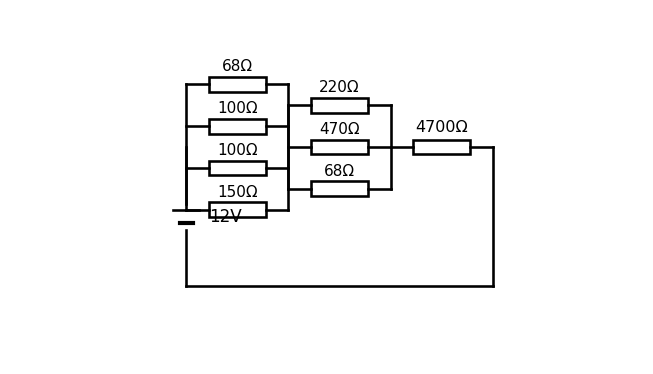

Q: Find the current through R6. | abstain: False
Components (with image regions): V1 <box>[262, 517, 308, 642]</box> (12V source); R1 <box>[285, 524, 441, 598]</box> (150Ω); R2 <box>[285, 412, 441, 486]</box> (100Ω); R3 <box>[285, 300, 441, 375]</box> (100Ω); R4 <box>[285, 188, 441, 263]</box> (68Ω); R5 <box>[441, 468, 598, 542]</box> (68Ω); R6 <box>[441, 356, 598, 430]</box> (470Ω); R7 <box>[441, 244, 598, 319]</box> (220Ω); R8 <box>[598, 356, 754, 430]</box> (4700Ω).
Concepts used: Ohm's law, parallel resistor combination, series resistor combination.

Topology: (R1||R2||R3||R4) + (R5||R6||R7) + R8 (combine parallel groups, then add in series).
Reduce: R1||R2||R3||R4: 1/(1/150+1/100+1/100+1/68) = 24.17 Ω; R5||R6||R7: 1/(1/68+1/470+1/220) = 46.77 Ω; R8 = 4700 Ω.
Equivalent resistance: R_eq = 4770.95 Ω.
Total current: I = V / R_eq = 12 / 4770.95 = 0.0025 A.
Answer: current through R6 = 0.0003 A.
Verification: V = I*R_eq: 0.0025*4770.95 = 12.00 ≈ 12 ✓; each parallel combo < its smallest

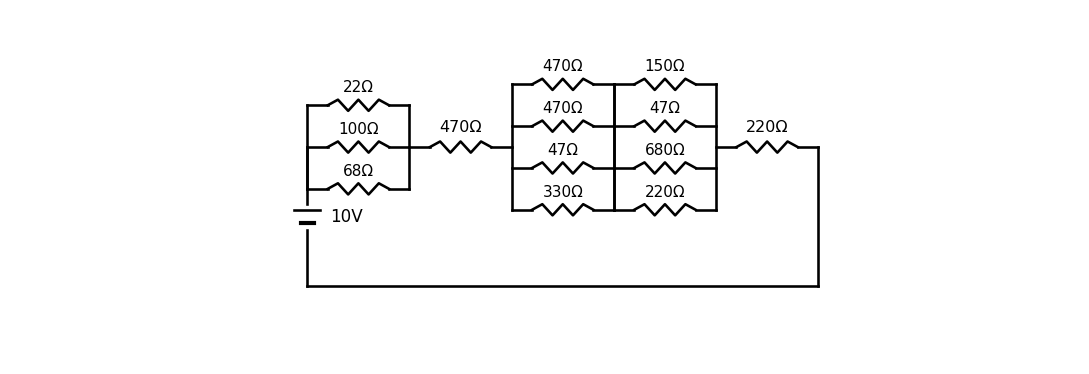

Q: Find the current through R9. | abstain: False
Components (with image regions): V1 <box>[269, 517, 296, 642]</box> (10V source); R1 <box>[282, 468, 376, 542]</box> (68Ω); R2 <box>[282, 356, 376, 430]</box> (100Ω); R3 <box>[282, 244, 376, 319]</box> (22Ω); R4 <box>[376, 356, 470, 430]</box> (470Ω); R5 <box>[470, 524, 564, 598]</box> (330Ω); R6 <box>[470, 412, 564, 486]</box> (47Ω); R7 <box>[470, 300, 564, 375]</box> (470Ω); R8 <box>[470, 188, 564, 263]</box> (470Ω); R9 <box>[564, 524, 658, 598]</box> (220Ω); R10 <box>[564, 412, 658, 486]</box> (680Ω); R11 <box>[564, 300, 658, 375]</box> (47Ω); R12 <box>[564, 188, 658, 263]</box> (150Ω); R13 <box>[658, 356, 751, 430]</box> (220Ω).
Concepts used: Ohm's law, parallel resistor combination, series resistor combination.

Topology: (R1||R2||R3) + R4 + (R5||R6||R7||R8) + (R9||R10||R11||R12) + R13 (combine parallel groups, then add in series).
Reduce: R1||R2||R3: 1/(1/68+1/100+1/22) = 14.25 Ω; R4 = 470 Ω; R5||R6||R7||R8: 1/(1/330+1/47+1/470+1/

In [11]:
random.shuffle(records)
n_val=int(len(records)*CONFIG["VAL_FRAC"])
val, train = records[:n_val], records[n_val:]
def dump(recs, name):
    with open(os.path.join(CONFIG["OUT_DIR"],name),"w") as f:
        for r in recs: f.write(json.dumps(r)+"\n")
dump(train,"train.jsonl"); dump(val,"val_synthetic.jsonl")
print(f"train: {len(train)}  val(synthetic): {len(val)}")

# spot-check a few
import textwrap
from IPython.display import display
for r in random.sample(train, 2):
    display(IPImage(os.path.join(IMG_DIR, r["image"])))
    print("Q:", r["question"], "| abstain:", r["abstain"])
    print(r["target_output"]); print("gold_components:", r["gold_components"]); print("-"*60)

# skill coverage across the training set (from structural tags)
from collections import Counter
cov = Counter(t for r in train for t in r["skills"])
print("\nskill coverage (train):")
for t,n in cov.most_common(): print(f"   {t:26s} {n}  ({100*n/len(train):.0f}%)")

## 9b. (v2) Mistake & correction data  *(optional, OFF by default)*

Set `INCLUDE_MISTAKES = True` in the config to also generate **correct + wrong** solution pairs — built on the **current pipeline**, so they span **all three families** (dc-resistor / reactive / bridge) and **all question types**, with both solutions in the same v1 worked-solution format. The injected errors are **perception-relevant** (the moat), not arithmetic slips:

- **value_misread** — reads a resistor's value wrong (×10 / ÷10)
- **omit_branch** — drops one branch of a parallel group
- **parallel_as_series** — adds parallel resistors instead of `1/R_eq = Σ1/R_i`
- **regime_confusion** — applies the wrong capacitor/inductor open-short rule (steady-state ↔ t=0)
- **bridge_collapse** — the classic "collapse a Wheatstone bridge as `(R1+R3)∥(R2+R4)`, ignore R5" mistake

Every mistake is **verified to actually change the asked quantity's answer** (by more than the eval's tolerance), so each row is a genuine chosen/rejected pair. Output `train_pairs.jsonl` supports two later uses:
- **Preference tuning (DPO):** `correct_solution` = chosen, `wrong_solution` = rejected.
- **Critique / error-detection SFT:** input = image + `wrong_solution`, target = `critique_target` (points at the error step and corrects it).

**This is a v2 stage that runs *after* v1 SFT posts a clear base-vs-tuned gain** — running DPO on a weak v1 just adds noise. Leave the flag `False` to produce the plain v1 dataset only; this section then does nothing.

In [ ]:
# ================= v2: MISTAKE / CORRECTION DATA (flag-gated, OFF by default) =================
# Modernized onto the current pipeline: ALL families (dc_resistor / reactive / bridge) and ALL
# question types, with correct + wrong solutions in the SAME v1 worked-solution format. Errors are
# perception-relevant (the moat): misread value, dropped parallel branch, parallel-as-series,
# capacitor/inductor regime confusion, and bridge-collapse. Each mistake is verified to actually
# change the asked quantity's answer (by > the eval's 3% tolerance). Numeric only (symbolic deferred).
# Each row supports DPO (correct=chosen, wrong=rejected) OR critique SFT (wrong -> critique_target).
# This is a v2 stage that runs AFTER v1 SFT succeeds — set CONFIG["INCLUDE_MISTAKES"]=True to build it.
if not CONFIG["INCLUDE_MISTAKES"]:
    print("INCLUDE_MISTAKES = False  ->  skipping v2 mistake data (v1 dataset only).")
else:
    from collections import Counter

    def _v2_answer_for(sol, chain, family, regime, quant, tid, source_v):
        """Value of the asked quantity from a solved sol (mirrors choose_question)."""
        if quant=="resistance": return sol["R_eq"]
        if quant=="current" and tid=="V1": return sol["I_total"]
        el=reactive_element(chain)
        if family=="reactive" and el is not None and tid==el.get("react_id"):
            q=reactive_quantities(chain, regime, source_v, sol)
            return {"voltage":q["v_react"],"current":q["i_react"],"charge":q.get("charge"),"energy":q["energy"]}[quant]
        comp=next(c for c in sol["comps"] if c["id"]==tid)
        I=sol["branch_currents"][tid]
        V=sol["node_voltages"][comp["nodes"][0]]-sol["node_voltages"][comp["nodes"][1]]
        return {"current":I,"voltage":V,"power":I*I*comp["value"]}[quant]

    def _v2_changed(a, b, rel=0.06):   # > eval's 3% tolerance -> wrong answer is unambiguously wrong
        if a is None or b is None: return a is not b
        if abs(a)<1e-9: return abs(b)>1e-6
        return abs(a-b) > rel*abs(a)

    def _v2_copy(chain):
        return [dict(e, **({"values":list(e["values"])} if "values" in e else {})) for e in chain]

    def _inj_value_misread(chain, regime, source_v, tid):
        cw=_v2_copy(chain); singles=[e for e in cw if e["kind"]=="R"]
        if not singles: return None
        e=random.choice(singles); true_v=e["value"]; e["value"]=true_v*random.choice([10,0.1])
        sw=solve_chain(cw, regime, source_v)
        if sw is None: return None
        return cw, regime, sw, dict(error_type="value_misread", targeted_skill="reading_values", first_step="Components",
            explanation=f"Misread {e['ids'][0]} as {e['value']:g}Ω instead of {true_v:g}Ω.",
            correction=f"Read the value carefully: {e['ids'][0]} is {true_v:g}Ω.")

    def _inj_omit_branch(chain, regime, source_v, tid):
        cw=_v2_copy(chain)
        blocks=[e for e in cw if e["kind"]=="P" and len(e["values"])>=2 and tid not in e["ids"]]
        if not blocks: return None
        e=random.choice(blocks); j=random.randrange(len(e["values"]))
        dropped_id=e["ids"][j]; dropped_v=e["values"][j]
        e["values"]=[v for k,v in enumerate(e["values"]) if k!=j]
        e["ids"]=[i for k,i in enumerate(e["ids"]) if k!=j]
        if len(e["values"])==1:
            i=cw.index(e); cw[i]={"kind":"R","value":e["values"][0],"ids":e["ids"]}
        sw=solve_chain(cw, regime, source_v)
        if sw is None: return None
        return cw, regime, sw, dict(error_type="omit_branch", targeted_skill="parallel_reduction", first_step="Components",
            explanation=f"Ignored the {dropped_v:g}Ω branch ({dropped_id}) when combining that parallel group.",
            correction="Every parallel branch carries current and must be included in 1/R_eq = Σ 1/R_i.")

    def _inj_parallel_as_series(chain, regime, source_v, tid):
        cw=_v2_copy(chain); idxs=[i for i,e in enumerate(cw) if e["kind"]=="P"]
        if not idxs: return None
        i=random.choice(idxs); e=cw[i]; ids=list(e["ids"]); vals=list(e["values"])
        cw[i:i+1]=[{"kind":"R","value":v,"ids":[cid]} for cid,v in zip(ids,vals)]   # treat parallel as series
        sw=solve_chain(cw, regime, source_v)
        if sw is None: return None
        return cw, regime, sw, dict(error_type="parallel_as_series", targeted_skill="parallel_reduction", first_step="Topology",
            explanation=f"Treated the parallel group ({'||'.join(ids)}) as if the resistors were in series and added them.",
            correction="Parallel resistors combine as 1/R_eq = Σ 1/R_i (smaller than the smallest), not by adding.")

    def _inj_regime_confusion(chain, regime, source_v, tid):
        if regime not in ("steady_state","t0"): return None
        rw="t0" if regime=="steady_state" else "steady_state"
        sw=solve_chain(chain, rw, source_v)
        if sw is None: return None
        el=reactive_element(chain); rid=el.get("react_id","the reactive element")
        exp=("Applied the t=0 rule at steady state" if regime=="steady_state" else "Applied the steady-state rule at t=0")
        return chain, rw, sw, dict(error_type="regime_confusion", targeted_skill="component_id_CL", first_step="Regime",
            explanation=f"{exp}: used the wrong open/short behavior for {rid}.",
            correction="At steady state a capacitor is OPEN and an inductor is a WIRE; at t=0 it is the reverse.")

    _RES_INJ=[_inj_value_misread, _inj_omit_branch, _inj_parallel_as_series]

    def _first_error_step(correct_solution, section):
        for i,l in enumerate(correct_solution.split("\n"),1):
            if section.lower() in l.lower(): return i
        return 4

    def _v2_pair(img, q, family, quant, tid, correct, wrong, val, val_w, err, boxes, skills, concepts):
        fs=_first_error_step(correct, err["first_step"]); cf=round_sig(val,5); wf=round_sig(val_w,5)
        return dict(image=img, question=q, family=family, question_type=quant, value_mode="numeric",
            correct_solution=correct, wrong_solution=wrong, correct_final=cf, wrong_final=wf,
            error_type=err["error_type"], targeted_skill=err["targeted_skill"], first_error_step=fs,
            error_explanation=err["explanation"], correction=err["correction"],
            critique_target=(f"There is an error at the {err['first_step']} step (step {fs}). {err['explanation']} "
                             f"{err['correction']} The correct {quant} is {num(val)} {UNIT[quant]}."),
            gold_boxes=boxes, gold_answer={"quantity":quant,"target_id":tid,"value":cf,"unit":UNIT[quant],"symbolic":False},
            skills=skills, concepts=concepts)

    def _build_chain_pair(idx):
        source_v=random.choice(CONFIG["SOURCE_VOLTS"]); family=random.choice(["dc_resistor","reactive"])
        if family=="reactive":
            chain=gen_reactive_chain(CONFIG["MAX_LINKS"], CONFIG["MAX_PARALLEL"]); regime=random.choice(["steady_state","t0"])
        else:
            chain=gen_dc_chain(CONFIG["MAX_LINKS"], CONFIG["MAX_PARALLEL"]); regime=None
        chain,_=assign_ids(chain); sol=solve_chain(chain, regime, source_v)
        if sol is None: return None
        sol["source_v"]=source_v
        q,quant,tid,val=choose_question(chain, family, regime, sol)
        injs=_RES_INJ[:] + ([_inj_regime_confusion] if family=="reactive" else []); random.shuffle(injs)
        for inj in injs:
            r=inj(chain, regime, source_v, tid)
            if not r: continue
            cw, rw, sw, err = r; sw["source_v"]=source_v
            try: val_w=_v2_answer_for(sw, cw, family, rw, quant, tid, source_v)
            except Exception: continue
            if not _v2_changed(val, val_w): continue
            img=f"pair_{idx:06d}.png"; path=os.path.join(IMG_DIR,img)
            _,boxes=render_chain_img(chain, path, source_v); boxes=domain_randomize(path, boxes)
            correct=worked_solution_v2(chain, family, regime, source_v, sol, quant, tid, val, boxes)
            wrong  =worked_solution_v2(cw, family, rw, source_v, sw, quant, tid, val_w, boxes)
            return _v2_pair(img, q, family, quant, tid, correct, wrong, val, val_w, err, boxes,
                            skills_of(chain,family,regime,quant), concepts_of(chain,family,regime))
        return None

    def _bridge_wrong_body(vals, V, quant, tid, val_w, boxes, Rw, Iw):
        R1,R2,R3,R4,R5=vals
        L=[_bridge_grounded(vals, V, boxes),
           "Concepts used: Ohm's law, series resistor combination, parallel resistor combination.",
           "Topology: treat it as two series arms in parallel — (R1+R3) || (R2+R4) — ignoring the bridge R5.",
           f"Reduce: R1+R3 = {num(R1+R3)} Ω, R2+R4 = {num(R2+R4)} Ω; in parallel R_eq = {Rw:.2f} Ω.",
           f"Total current: I = V / R_eq = {V:g} / {Rw:.2f} = {num(Iw)} A.",
           "Since the arms look symmetric, assume no current flows through the bridge R5."]
        if quant=="resistance": L.append(f"Answer: R_eq = {val_w:.2f} Ω.")
        elif quant=="current" and tid=="R5": L.append("Answer: current through R5 = 0 A (assumed).")
        elif quant=="voltage" and tid=="R5": L.append("Answer: voltage across R5 = 0 V (assumed).")
        elif quant=="current" and tid=="V1": L.append(f"Answer: total current = {num(val_w)} A.")
        L.append("Verification: (skipped the KCL check).")
        final=json.dumps({"quantity":quant,"target_id":tid,"value":round_sig(val_w,4),"unit":UNIT[quant],"symbolic":False,"abstain":False})
        return "\n".join(L)+"\nFINAL: "+final

    def _build_bridge_pair(idx):
        source_v=random.choice(CONFIG["SOURCE_VOLTS"]); vals=gen_bridge(); bsol=solve_bridge(vals, source_v)
        q,quant,tid,val=choose_bridge_question(bsol); R1,R2,R3,R4,R5=vals
        left=R1+R3; right=R2+R4; Rw=left*right/(left+right); Iw=source_v/Rw    # collapse ignores R5
        val_w={"resistance":Rw,"current":(0.0 if tid=="R5" else Iw)}.get(quant)
        if quant=="voltage" and tid=="R5": val_w=0.0
        if val_w is None or not _v2_changed(val, val_w): return None
        img=f"pair_{idx:06d}.png"; path=os.path.join(IMG_DIR,img)
        _,boxes=render_bridge_img(vals, path, source_v); boxes=domain_randomize(path, boxes)
        correct=bridge_solution(vals, source_v, bsol, quant, tid, val, boxes)
        wrong=_bridge_wrong_body(vals, source_v, quant, tid, val_w, boxes, Rw, Iw)
        err=dict(error_type="bridge_collapse", targeted_skill="non_series_parallel", first_step="Topology",
            explanation="Collapsed the bridge as (R1+R3)||(R2+R4), ignoring the bridge resistor R5, and assumed no current through R5.",
            correction="A bridge is NOT series/parallel reducible; solve node voltages (KCL). R5 carries current unless the bridge is balanced.")
        return _v2_pair(img, q, "bridge", quant, tid, correct, wrong, val, val_w, err, boxes,
                        sorted(["ohms_law","non_series_parallel","bridge",f"q_{quant}"]),
                        ["Ohm's law","Kirchhoff's current law (nodal analysis)"])

    def _make_pair(idx):
        return _build_bridge_pair(idx) if random.random()<0.2 else _build_chain_pair(idx)

    pairs=[]; tries=0
    while len(pairs)<CONFIG["N_PAIRS"] and tries<CONFIG["N_PAIRS"]*8:
        tries+=1
        try: p=_make_pair(len(pairs))
        except Exception: p=None
        if p: pairs.append(p)
    with open(os.path.join(CONFIG["OUT_DIR"],"train_pairs.jsonl"),"w") as f:
        for r in pairs: f.write(json.dumps(r)+"\n")
    print(f"v2: wrote {len(pairs)} correct/wrong pairs -> train_pairs.jsonl  ({tries} tries)")
    print("  families:      ", dict(Counter(p['family'] for p in pairs)))
    print("  question types:", dict(Counter(p['question_type'] for p in pairs)))
    print("  error types:   ", dict(Counter(p['error_type'] for p in pairs)))
    print("\n  example critique:", pairs[0]["critique_target"])

## 10. Real-world evaluation set (hand-labeled — do NOT auto-scrape)

Your headline number is **transfer to real diagrams**. The honest, license-clean way to build this is a small hand-labeled set, kept entirely out of training:

- **Open datasets for real images/vocabulary:** Masala-CHAI (4,300 annotated diagrams + SPICE netlists) and CircuitNet (MIT license) are permissively licensed — check each repo's license before redistributing anything derived.
- **AP/textbook problems:** use them for *evaluation only*; don't redistribute copyrighted images. Photograph/scan ~50–100, then fill in the template below by hand.

Auto-scraping AP problem images is a copyright and quality minefield — skip it. Hand-label a small, honest eval set instead.

In [12]:
# Template for a hand-labeled real-world eval record (matches the generalized schema the
# eval harness reads). Fill one dict per real diagram. The easiest path: describe the circuit
# as a `chain`, run it through solve_chain(...) + render/measure boxes, and let the helper fill
# gold_answer / gold_values for you — then you only hand-check the numbers.
def make_real_eval_record(image, question, chain, regime, source_v, quantity, target_id, gold_boxes,
                          family="dc_resistor", abstain=False, source=""):
    chain,_=assign_ids(chain); sol=solve_chain(chain, regime, source_v); sol["source_v"]=source_v
    # compute the answer value for the requested quantity from the exact solver
    if quantity=="resistance": val=sol["R_eq"]
    elif quantity=="current" and target_id in (None,"V1"): val=sol["I_total"]
    elif family=="reactive":
        q=reactive_quantities(chain, regime, source_v, sol)
        val={"voltage":q["v_react"],"current":q["i_react"],"charge":q.get("charge"),"energy":q["energy"]}[quantity]
    else:
        comp=next(c for c in sol["comps"] if c["id"]==target_id); I=sol["branch_currents"][target_id]
        V=sol["node_voltages"][comp["nodes"][0]]-sol["node_voltages"][comp["nodes"][1]]
        val={"current":I,"voltage":V,"power":I*I*comp["value"]}[quantity]
    return {
        "image":image, "question":question, "family":family, "regime":regime,
        "question_type":quantity, "abstain":bool(abstain),
        "gold_components":_gold_components(chain),
        "gold_topology":topology_str(chain),
        "gold_answer":{"quantity":quantity,"target_id":target_id,
                       "value":(None if abstain else round_sig(val,6)),"unit":UNIT[quantity]},
        "gold_values":dict(R_eq=round(sol["R_eq"],3), I_total=round(sol["I_total"],5),
            node_voltages={str(k):round(v,4) for k,v in sol["node_voltages"].items()},
            branch_currents={k:round(v,5) for k,v in sol["branch_currents"].items()}),
        "concepts":concepts_of(chain, family, regime),
        "gold_boxes":gold_boxes,     # {"V1":[x0,y0,x1,y1], "R1":[...], ...} normalized 0-1000, measured by hand
        "source":source,
    }

# Example: a real "R1 in series with (R2||R3)" diagram, asking for current through R2.
_example = make_real_eval_record(
    image="real/ap_2019_q3.png",
    question="Find the current through R2.",
    chain=[{"kind":"R","value":100.0},{"kind":"P","values":[220.0,330.0]}],
    regime=None, source_v=12.0, quantity="current", target_id="R2",
    gold_boxes={"V1":[40,480,110,650],"R1":[150,300,340,380],
                "R2":[430,300,700,380],"R3":[430,420,700,500]},
    family="dc_resistor", source="AP Physics C 2019 (eval only, not redistributed)")

os.makedirs(os.path.join(CONFIG["OUT_DIR"],"real"), exist_ok=True)
with open(os.path.join(CONFIG["OUT_DIR"],"real_eval_TEMPLATE.json"),"w") as f:
    json.dump([_example], f, indent=2)
print("wrote real_eval_TEMPLATE.json — one worked example; add more hand-labeled real diagrams the same way")
print("example gold_answer:", _example["gold_answer"])

wrote real_eval_TEMPLATE.json — fill it in with hand-labeled real diagrams


## 11. Save to Google Drive

The Colab working directory (`/content/`) is wiped when the runtime disconnects, so we persist the dataset to Google Drive. This cell zips the dataset and copies the zip into `MyDrive/CircuitSight/`. Mounting Drive will pop up an authorization prompt the first time. Change `DRIVE_FOLDER` if you want a different location.

In [13]:
# Zip the dataset into a folder under /content for manual download.
import shutil, os

OUT_FOLDER = "/content/downloads"
os.makedirs(OUT_FOLDER, exist_ok=True)

# make the zip, then move it into the folder
tmp = shutil.make_archive("circuitsight_dataset", "zip", CONFIG["OUT_DIR"])
dest = os.path.join(OUT_FOLDER, "circuitsight_dataset.zip")
shutil.move(tmp, dest)

size_mb = round(os.path.getsize(dest) / 1e6, 1)
print(f"Zip ready ({size_mb} MB) at: {dest}")
print("Download it from the file browser: folder icon (left sidebar) -> downloads -> "
      "right-click circuitsight_dataset.zip -> Download")

Zip ready (129.8 MB) at: /content/downloads/circuitsight_dataset.zip
Download it from the file browser: folder icon (left sidebar) -> downloads -> right-click circuitsight_dataset.zip -> Download


## 12. How this feeds the fine-tuning notebook

Each JSONL row is one training example. In the VLM fine-tuning notebook (Unsloth `FastVisionModel`, Qwen2.5-VL-3B, 4-bit QLoRA), map a row to a chat sample like:

```python
{"messages": [
  {"role":"user","content":[
      {"type":"image","image": <PIL image from row["image"]>},
      {"type":"text","text": row["question"] +
        "\nList the components, state the topology, then solve step by step."}]},
  {"role":"assistant","content":[{"type":"text","text": row["target_output"]}]},
]}
```

**Evaluation (the point of the layered labels):** the harness parses the model's output (preferring the `FINAL: {quantity, target_id, value, unit, abstain}` line) and scores separate axes against the gold — component identification (count **and** type: R/C/L), **reactive component-type accuracy** (cap vs inductor — the "spatial blindness" number), grounding (IoU ≥ 0.5) + grounding-hallucination, **step-verified** solve (final answer **and** the `R_eq` intermediate), fabrication vs. honest-abstention, and concept-hallucination — plus an answer-accuracy breakdown by question type. Report each **base vs. tuned**, and keep the hand-labeled real set for the transfer number.



img_008808.png  |  Q: Find the current through R3.


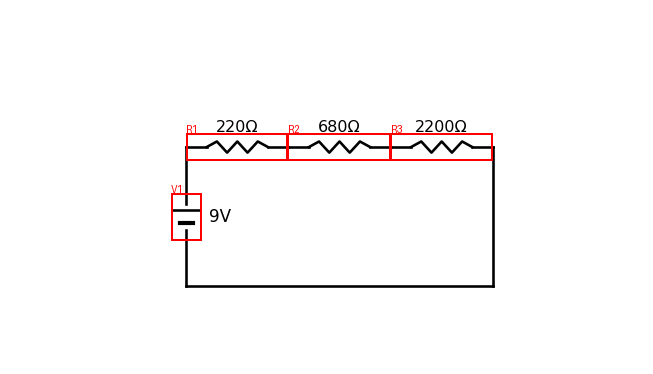


img_003716.png  |  Q: Find the current through R1.


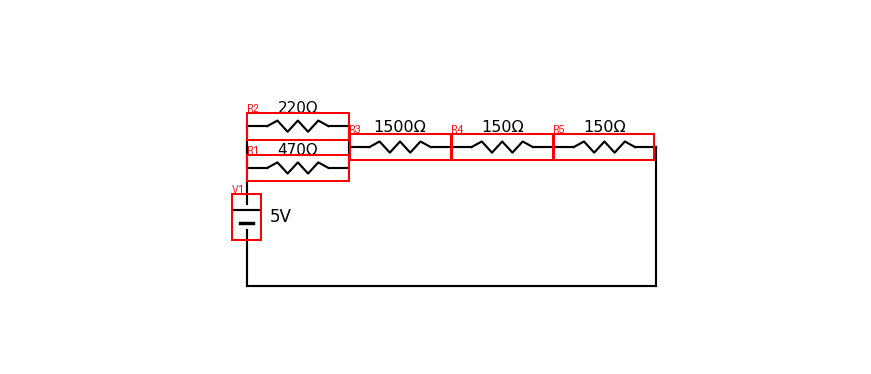


img_008827.png  |  Q: Find the current through R2.


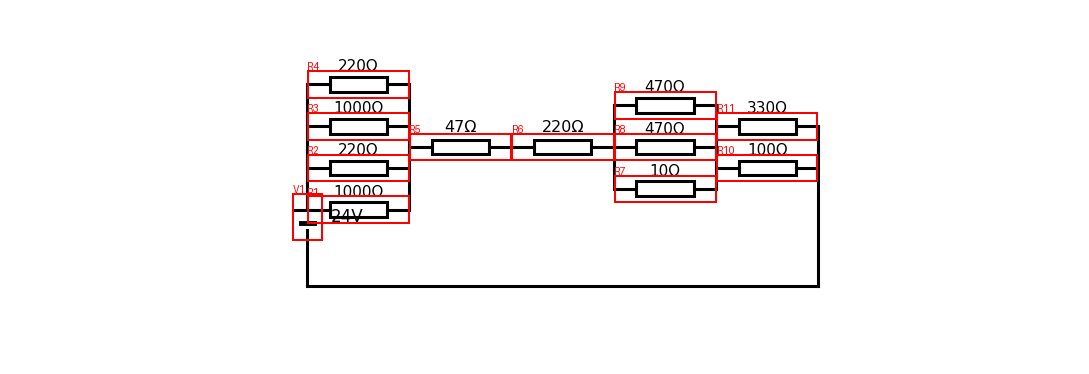


img_006617.png  |  Q: Find the current through R1.


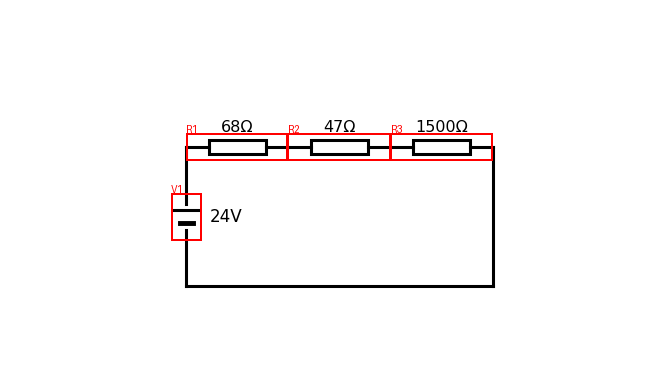


img_001543.png  |  Q: Find the current through R14.


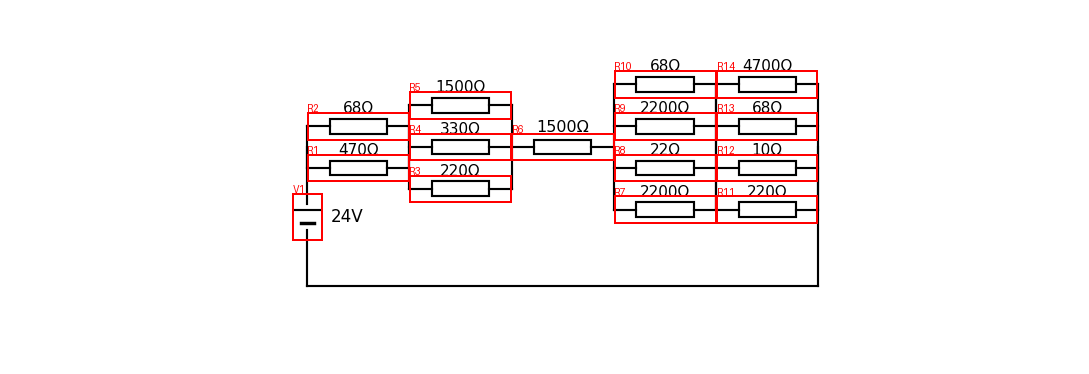


img_000960.png  |  Q: Find the current through R1.


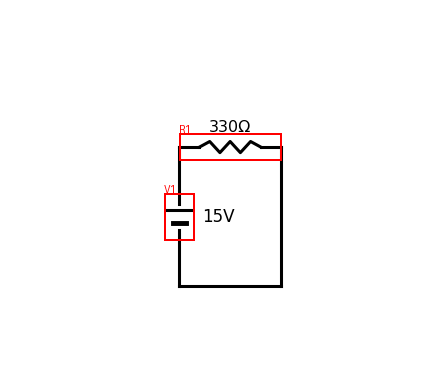


img_008622.png  |  Q: Find the current through R3.


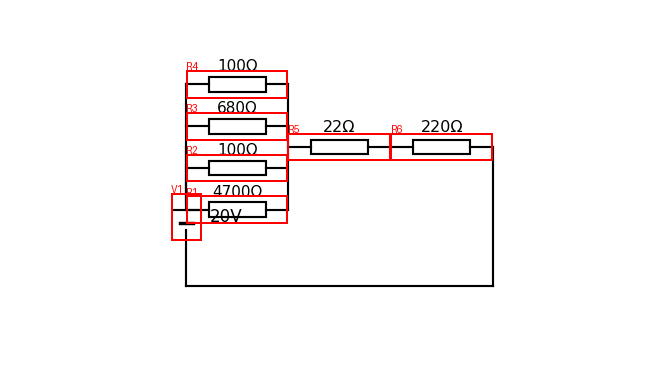


img_000556.png  |  Q: Find the current through R1.


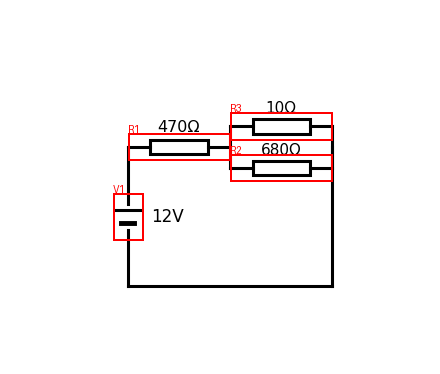

In [14]:
import json, os, random
from PIL import Image, ImageDraw
from IPython.display import Image as IPImage, display

DS = "circuitsight_dataset"   # adjust if needed
rows = [json.loads(l) for l in open(f"{DS}/train.jsonl")]

# pick 8 random non-abstain images
sample = random.sample([r for r in rows if not r["abstain"]], 8)

for r in sample:
    img = Image.open(f"{DS}/images/{r['image']}").convert("RGB")
    W, H = img.size
    d = ImageDraw.Draw(img)
    for cid, b in r["gold_boxes"].items():
        px = [b[0]*W/1000, b[1]*H/1000, b[2]*W/1000, b[3]*H/1000]
        d.rectangle(px, outline=(255, 0, 0), width=2)
        d.text((px[0], px[1]-10), cid, fill=(255, 0, 0))
    print(f"\n{r['image']}  |  Q: {r['question']}")
    display(img)   # shows inline, one after another